# Ứng Dụng Machine Learning trong Dự Đoán Khả Năng Rời Bỏ Dịch Vụ của Khách Hàng tại Ngân Hàng Việt Nam
### CS114 - Máy học | Nhóm 3

**Dataset:** Vietnam Bank Churn Dataset - 2025 (Kaggle)

**Models:** Logistic Regression, Decision Tree, Random Forest,  XGBoost

**Bài toán:** Classification (Binary Classification)

**Sample size:** 80,000 dòng (Imbalanced)

---

## Import thư viện và load data

In [1]:
# Basic
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve
)
import xgboost as xgb

# Imbalanced
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# SHAP
try:
    import shap
    SHAP_OK = True
except ImportError:
    print('Cài shap: pip install shap')
    SHAP_OK = False


In [2]:
# ── Load dữ liệu trên Google Colab ─────────────────────────────────────
# Cách 1: Upload file CSV thủ công (kéo thả hoặc dùng files.upload)
from google.colab import files
import io

print('Chọn file bank_churn_dataset_80k.csv từ máy tính...')
uploaded = files.upload()

# Đọc file vừa upload
filename = list(uploaded.keys())[0]
print(f'\nĐã upload: {filename}')


Chọn file bank_churn_dataset_80k.csv từ máy tính...


Saving bank_churn_dataset_80k.csv to bank_churn_dataset_80k.csv

Đã upload: bank_churn_dataset_80k.csv


In [3]:
# ── Đọc dataset ─────────────────────────────────────────────────────────
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()


Shape: (80000, 26)
Columns: ['id', 'full_name', 'credit_sco', 'gender', 'age', 'occupation', 'balance', 'monthly_ir', 'address', 'origin_province', 'tenure_ye', 'married', 'nums_card', 'nums_service', 'active_member', 'last_active_date', 'last_transaction_month', 'created_date', 'exit', 'customer_segment', 'engagement_score', 'loyalty_level', 'digital_behavior', 'risk_score', 'risk_segment', 'cluster_group']


,id,full_name,credit_sco,gender,age,occupation,balance,monthly_ir,address,origin_province,...,last_transaction_month,created_date,exit,customer_segment,engagement_score,loyalty_level,digital_behavior,risk_score,risk_segment,cluster_group
0,1,Đặng Văn Vũ,725,male,55,Chủ Doanh nghiệp nhỏ,177306004,121000000,Phường An Hội (BT),TP. Hồ Chí Minh,...,91038993,27/02/2025,False,Priority,90,Bronze,mobile,0.0359,Low,4
1,2,Bùi Hữu Phúc,689,male,45,Nội trợ/Sinh viên,1927416,5000000,Phường Bến Thành (Q1),Đồng Nai,...,3255569,29/07/2021,False,Mass,63,Gold,mobile,0.2664,Low,2
2,3,Lê Văn Mai,702,female,44,Chủ Doanh nghiệp nhỏ,304931745,109000000,Phường Hòa Bình (Q11),TP. Hồ Chí Minh,...,0,03/03/2021,False,Priority,36,Silver,offline,0.1343,Low,4
3,4,Dương Trần Nhiên,766,male,44,Chủ Doanh nghiệp nhỏ,50615501,79000000,Phường 7 (Q7),TP. Hồ Chí Minh,...,0,12/02/2022,False,Priority,23,Bronze,offline,0.2185,Low,4
4,5,Dương Thu Linh,677,female,77,Giáo viên/Giảng viên,40532432,25000000,Phường Thắng Lợi (Q10),TP. Hồ Chí Minh,...,0,24/07/2022,False,Emerging,23,Bronze,offline,0.2942,Low,2


In [4]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (80000, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      80000 non-null  int64  
 1   full_name               80000 non-null  object 
 2   credit_sco              80000 non-null  int64  
 3   gender                  80000 non-null  object 
 4   age                     80000 non-null  int64  
 5   occupation              80000 non-null  object 
 6   balance                 80000 non-null  int64  
 7   monthly_ir              80000 non-null  int64  
 8   address                 80000 non-null  object 
 9   origin_province         80000 non-null  object 
 10  tenure_ye               80000 non-null  int64  
 11  married                 80000 non-null  int64  
 12  nums_card               80000 non-null  int64  
 13  nums_service            80000 non-null  int64  
 14  active_member      

,id,credit_sco,age,balance,monthly_ir,tenure_ye,married,nums_card,nums_service,last_transaction_month,engagement_score,risk_score,cluster_group
count,80000.000000,80000.000000,80000.000000,8.000000e+04,8.000000e+04,80000.000000,80000.000000,80000.000000,80000.000000,8.000000e+04,80000.000000,80000.000000,80000.000000
mean,40000.500000,684.321137,49.381862,6.118320e+07,3.778820e+07,1.777250,0.970825,2.634688,3.564425,8.831755e+06,31.725400,0.269260,1.971037
std,23094.155105,51.169733,15.067480,8.868620e+07,3.655107e+07,1.315828,0.694698,1.218556,2.002448,3.378683e+07,23.474862,0.091891,1.040763
min,1.000000,495.000000,20.000000,4.086630e+05,3.000000e+06,0.000000,0.000000,1.000000,1.000000,0.000000e+00,7.000000,0.017300,1.000000
25%,20000.750000,649.000000,38.000000,1.462592e+07,1.400000e+07,1.000000,1.000000,2.000000,2.000000,0.000000e+00,16.000000,0.200400,1.000000
50%,40000.500000,682.000000,47.000000,3.090276e+07,2.300000e+07,2.000000,1.000000,2.000000,3.000000,0.000000e+00,22.000000,0.277400,2.000000
75%,60000.250000,718.000000,58.000000,6.960994e+07,4.700000e+07,3.000000,1.000000,3.000000,5.000000,0.000000e+00,38.000000,0.338900,2.000000
max,80000.000000,800.000000,90.000000,1.000000e+09,2.160000e+08,4.000000,3.000000,5.000000,8.000000,6.000000e+08,100.000000,0.540400,4.000000


In [5]:
# Check missing values
missing = df.isnull().sum()
missing = missing[missing > 0]

print("Missing values:\n", missing)

Missing values:
 Series([], dtype: int64)


In [6]:
# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


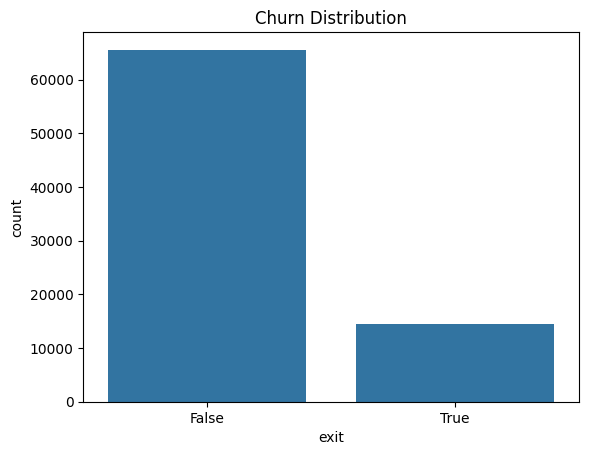

,proportion
exit,
False,82.0
True,18.0


In [7]:
# Target distribution
sns.countplot(x='exit', data=df)
plt.title("Churn Distribution")
plt.show()

df['exit'].value_counts(normalize=True) * 100

## EDA

### Phân tích đơn biến

In [8]:
# Numerical features — all numeric columns except target
num_cols = [c for c in df.select_dtypes(include='number').columns if c != 'exit']

print("Numerical columns:", num_cols)


Numerical columns: ['id', 'credit_sco', 'age', 'balance', 'monthly_ir', 'tenure_ye', 'married', 'nums_card', 'nums_service', 'last_transaction_month', 'engagement_score', 'risk_score', 'cluster_group']


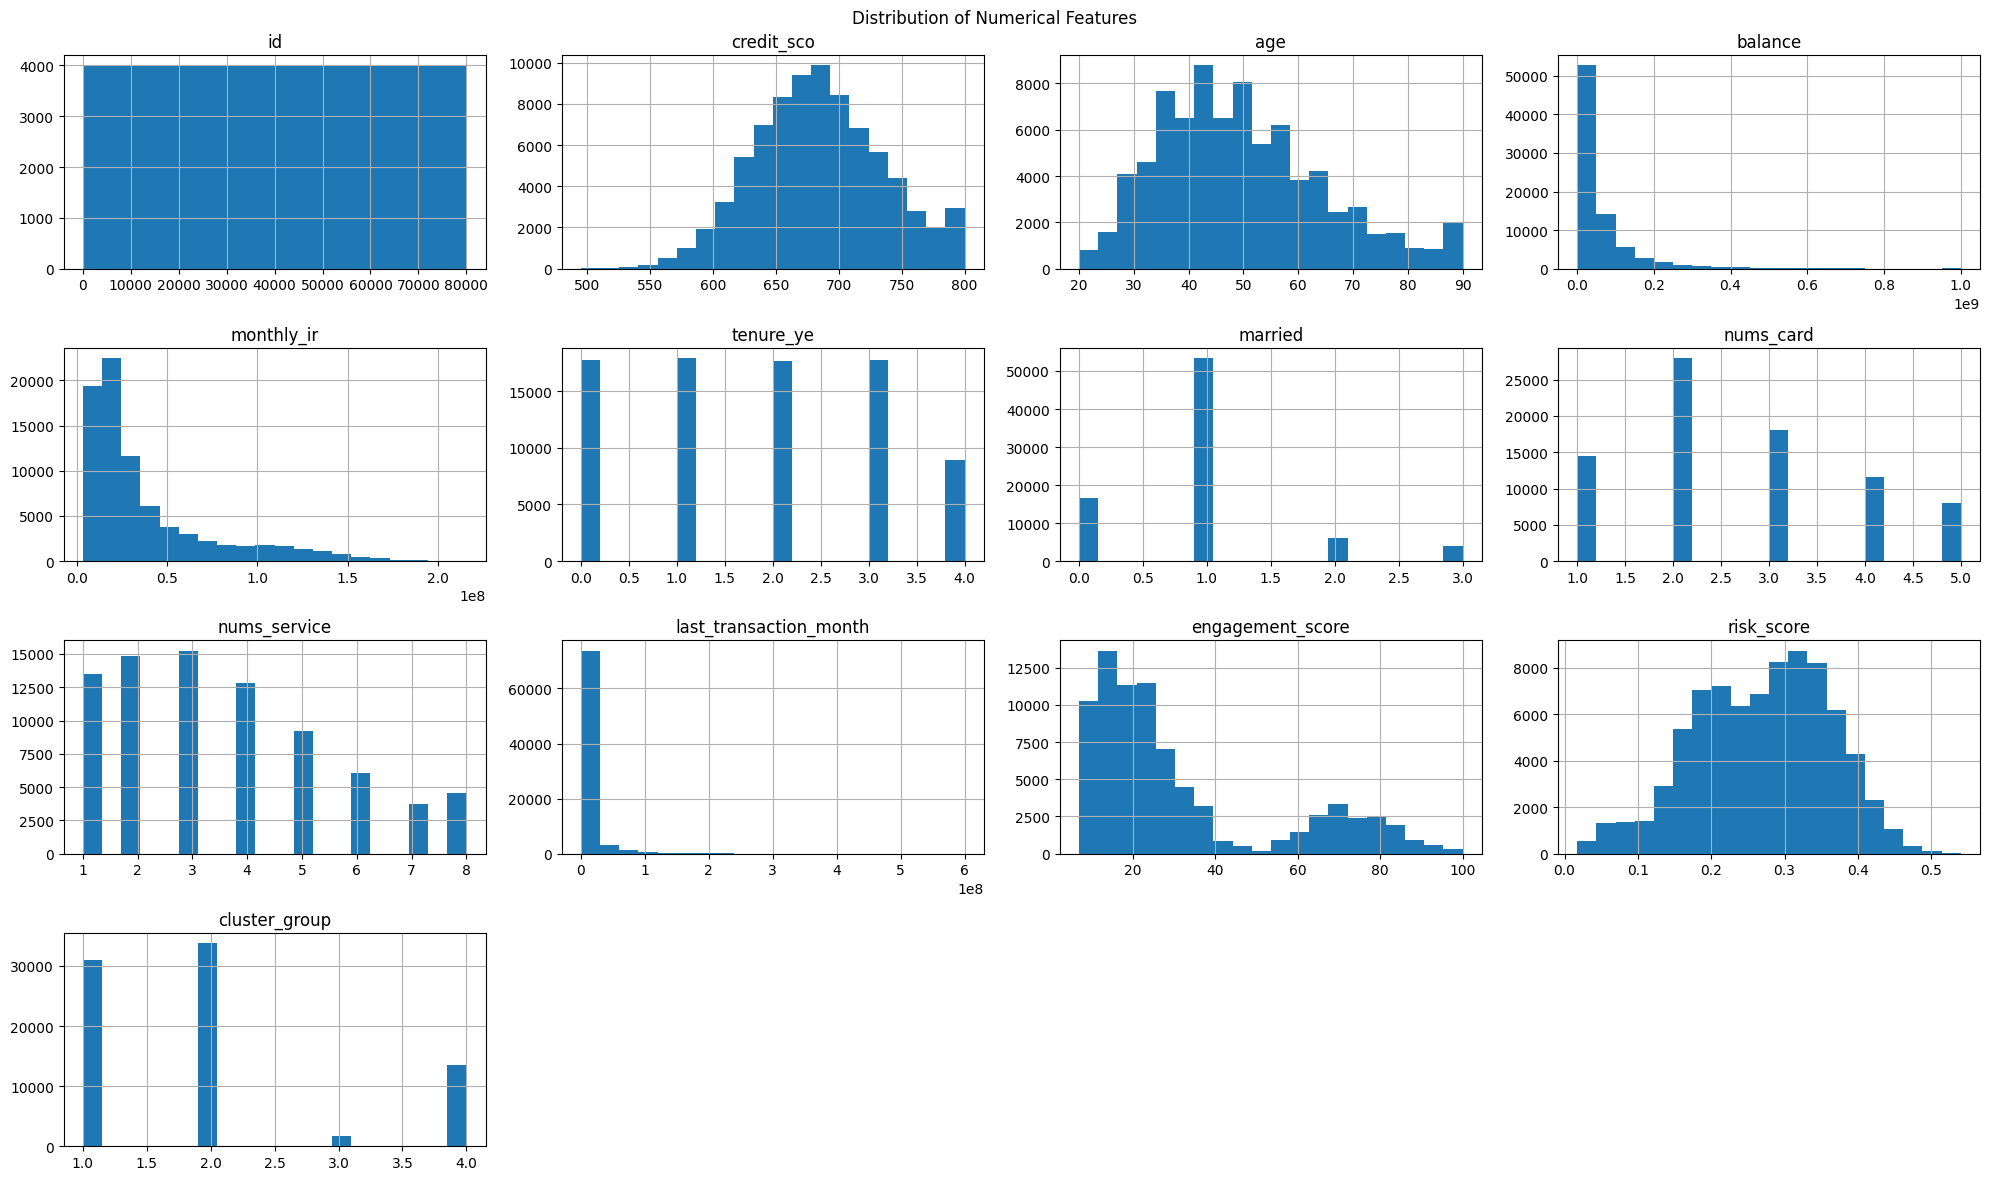

In [9]:
# num_cols = ['credit_sco', 'age', 'balance', 'monthly_ir', 'tenure_ye', 'married', 'nums_card', 'nums_service', 'last_transaction_month', 'engagement_score', 'risk_score', 'cluster_group']

df[num_cols].hist(bins=20, figsize=(20, 12))
plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()


In [10]:
# Categorical features — all object columns
cat_cols = [c for c in df.select_dtypes(include='object').columns]
print("Categorical columns:", cat_cols)

# cat_cols = ['gender', 'occupation', 'origin_province', 'customer_segment', 'loyalty_level', 'digital_behavior']

Categorical columns: ['full_name', 'gender', 'occupation', 'address', 'origin_province', 'last_active_date', 'created_date', 'customer_segment', 'loyalty_level', 'digital_behavior', 'risk_segment']


In [11]:
for col in cat_cols:
    freq_df = (
        df[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="count")
    )
    freq_df["pct"] = (freq_df["count"] / len(df) * 100).round(4)

    print(f"\n===== Frequency Table: {col} =====")
    display(freq_df)


===== Frequency Table: full_name =====


,full_name,count,pct
0,Lê Minh Quang,42,0.0525
1,Phạm Anh Quang,41,0.0512
2,Vũ Đức Quang,41,0.0512
3,Mai Thanh Quang,40,0.0500
4,Mai Hữu Quang,38,0.0475
...,...,...,...
5095,Nguyễn Hữu Tùng,5,0.0062
5096,Đặng Thị Hưng,5,0.0062
5097,Nguyễn Hữu Huy,4,0.0050
5098,Đặng Văn Trung,4,0.0050



===== Frequency Table: gender =====


,gender,count,pct
0,male,40008,50.01
1,female,39992,49.99



===== Frequency Table: occupation =====


...

,loyalty_level,count,pct
0,Bronze,69252,86.5650
1,Silver,8977,11.2213
2,Gold,1771,2.2138



===== Frequency Table: digital_behavior =====


,digital_behavior,count,pct
0,offline,62824,78.53
1,mobile,17176,21.47



===== Frequency Table: risk_segment =====


,risk_segment,count,pct
0,Low,74753,93.4412
1,Medium,5247,6.5588


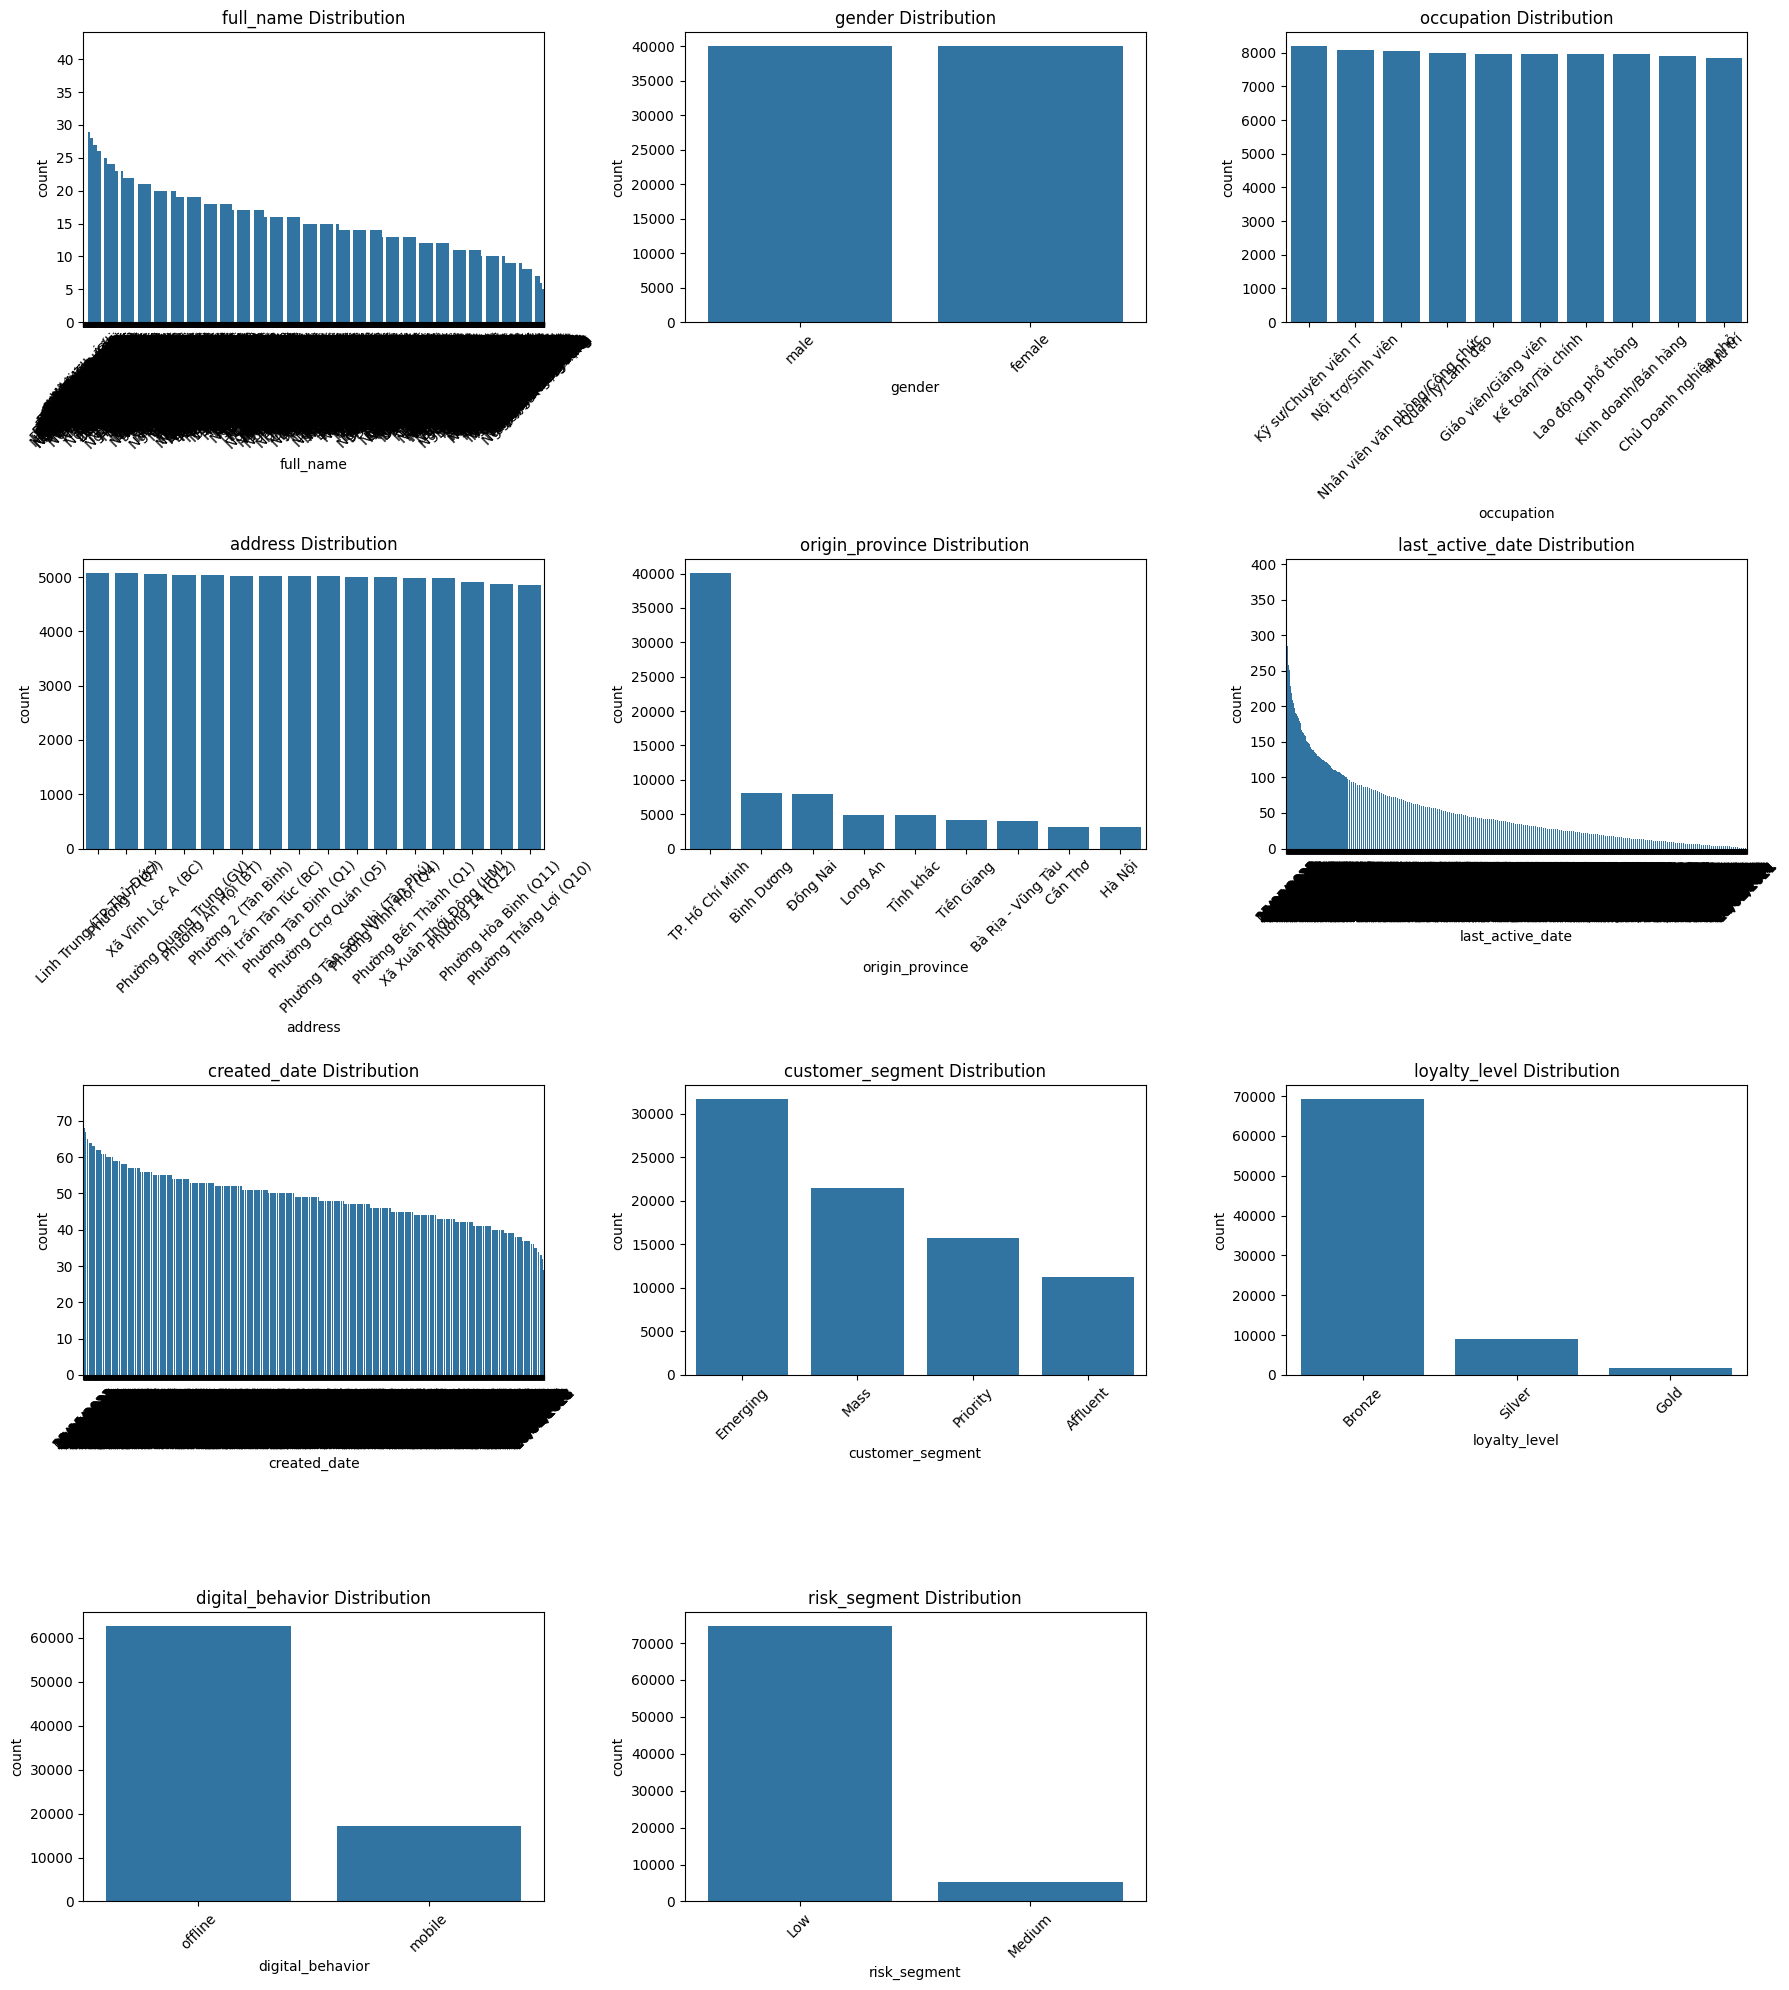

In [12]:
n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=df, ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(f"{col} Distribution")
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Phân tích đa biến

In [13]:
cat_cols = ['gender', 'occupation', 'origin_province', 'customer_segment', 'loyalty_level', 'digital_behavior']

num_cols = ['credit_sco', 'age', 'balance', 'monthly_ir', 'tenure_ye', 'married', 'nums_card', 'nums_service', 'last_transaction_month', 'engagement_score', 'risk_score', 'cluster_group']


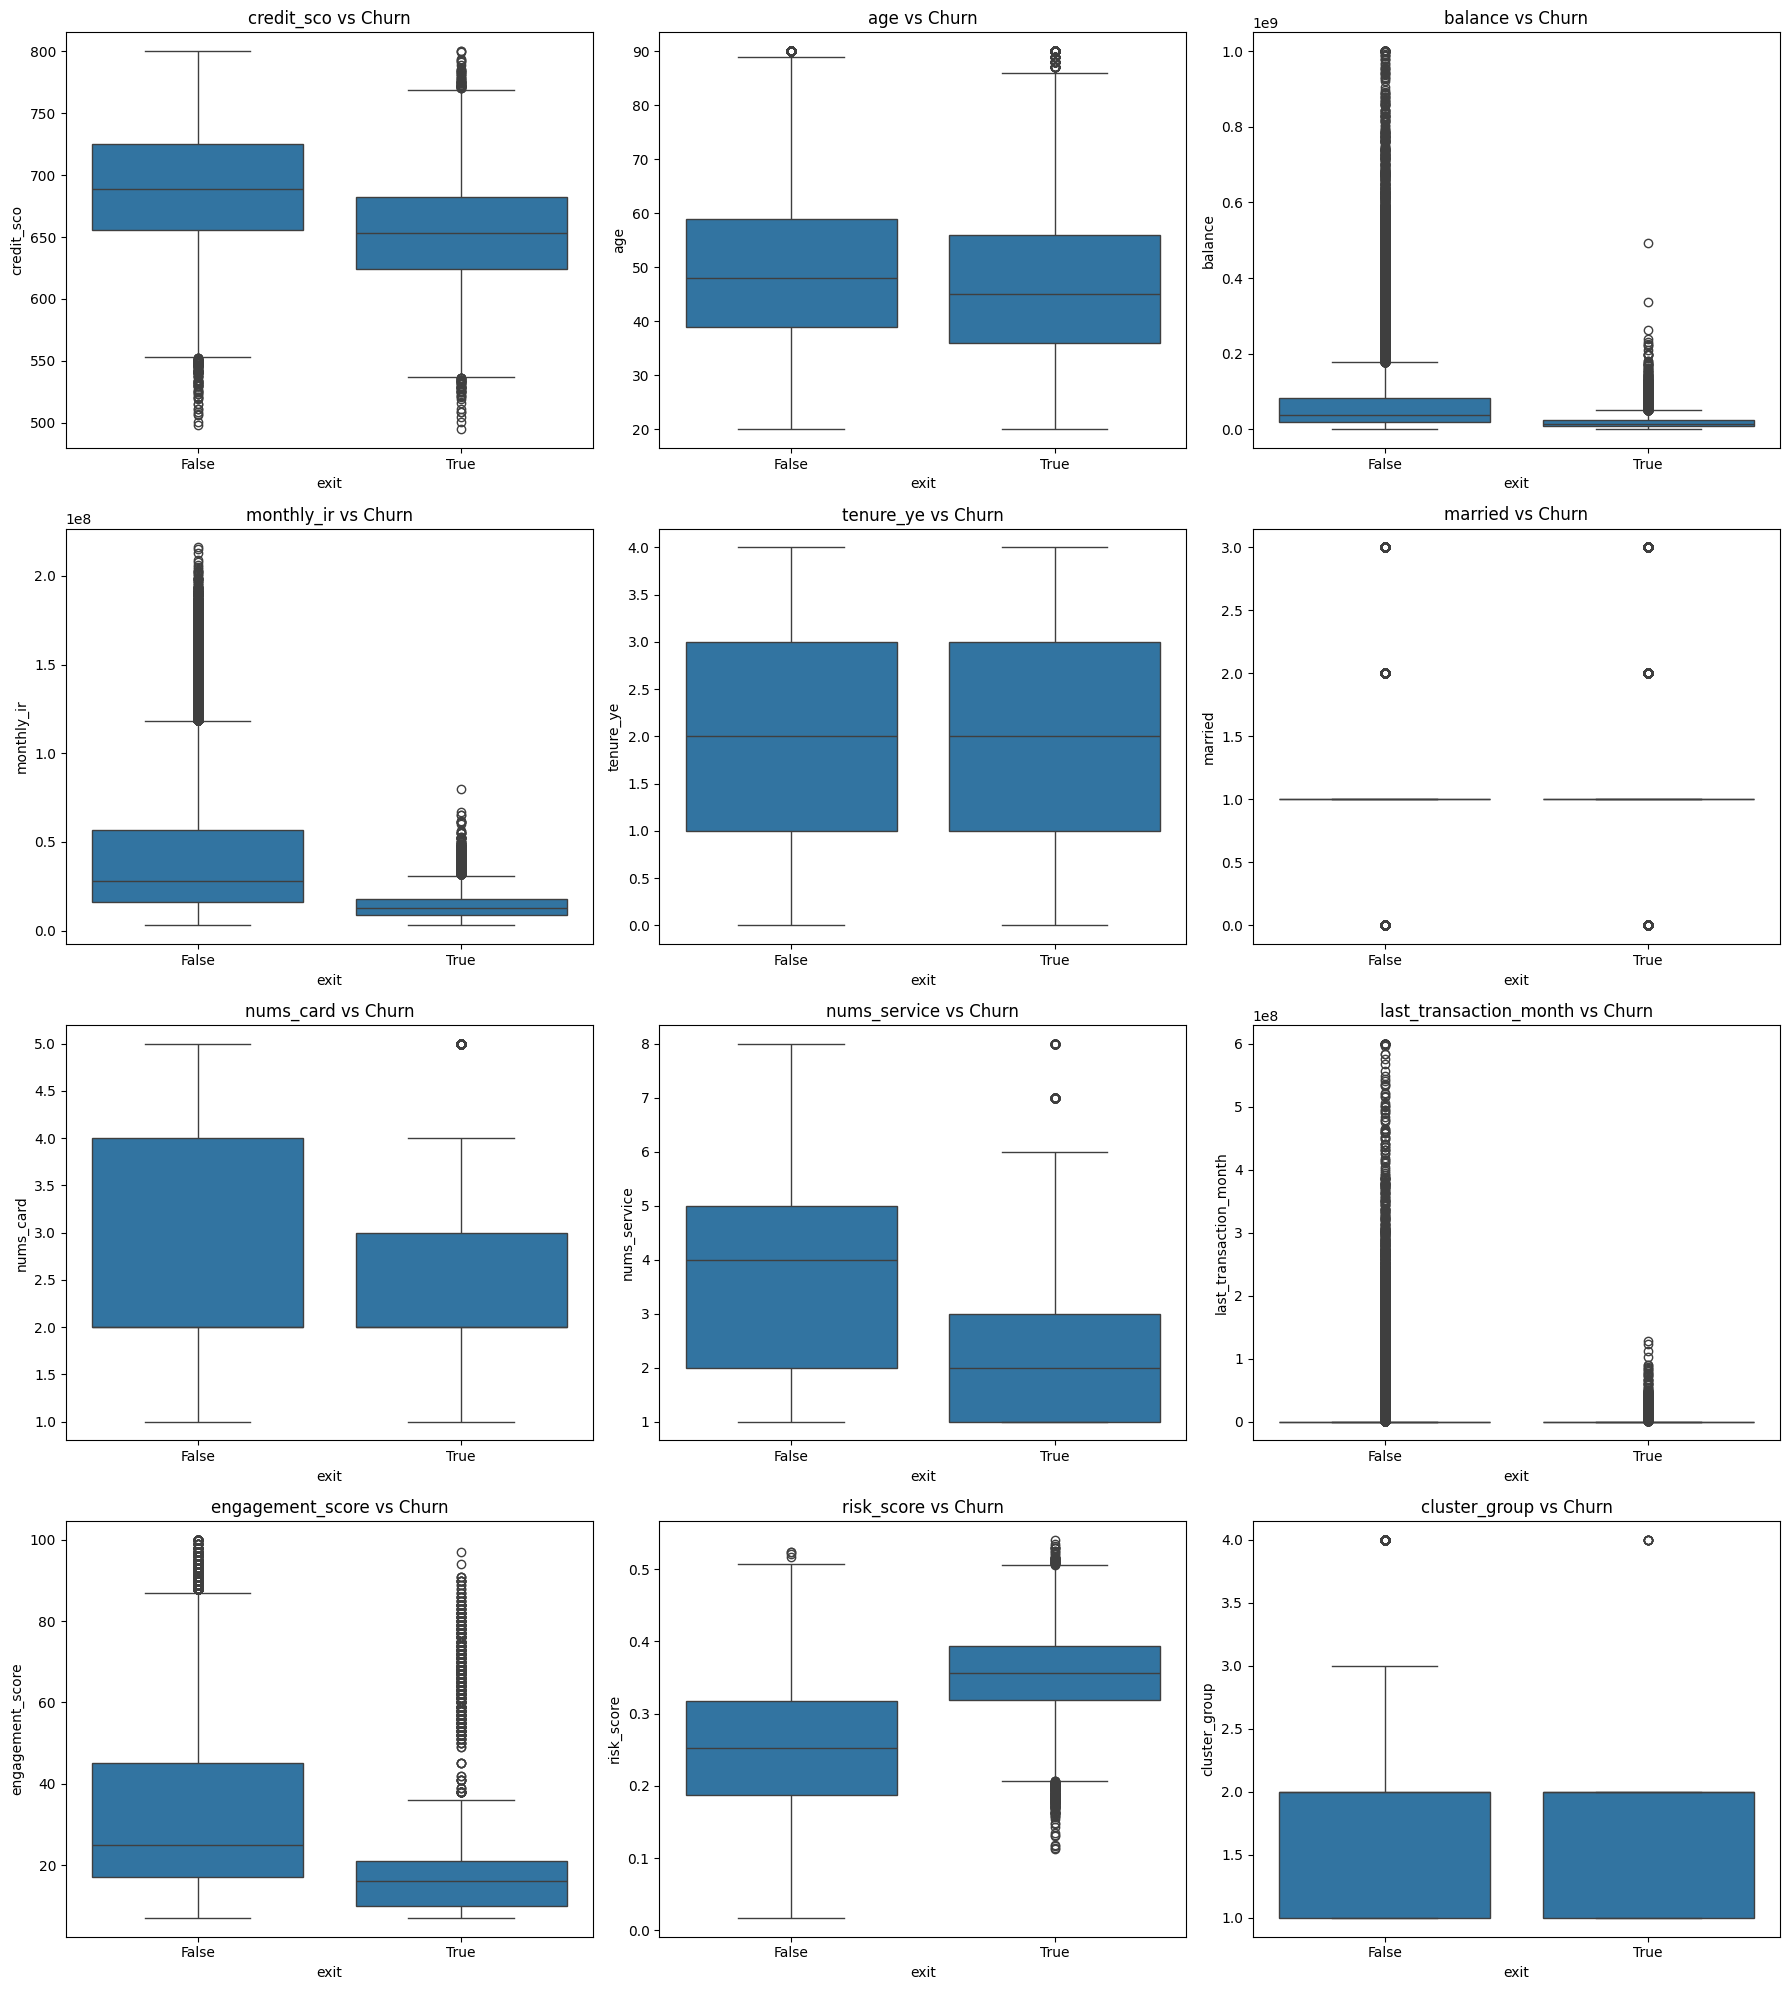

In [14]:
# Churn vs numerical
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x='exit', y=col, data=df, ax=axes[i])
    axes[i].set_title(f"{col} vs Churn")

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

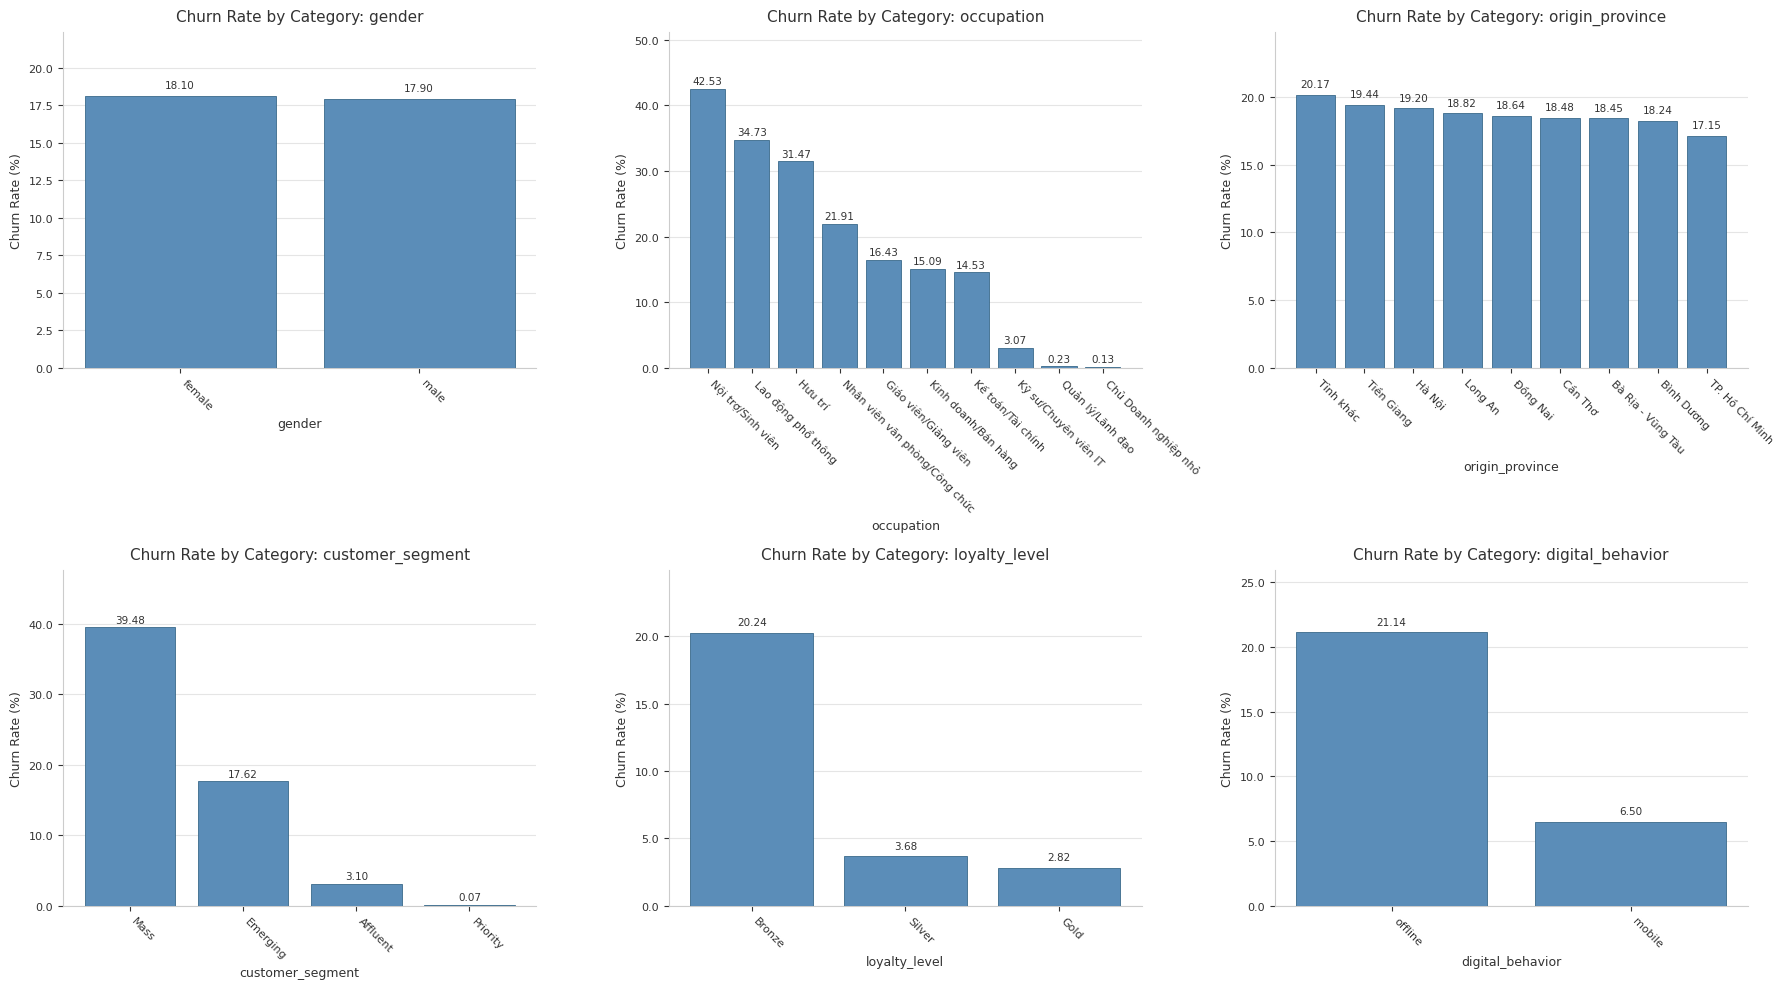

In [15]:
# Churn vs categorical
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import math

# ── Shared style constants (match your boxplot palette) ──────────────────────
BOX_COLOR   = "#5B8DB8"   # seaborn default blue used in the boxplots
EDGE_COLOR  = "#3A6A8A"
TEXT_COLOR  = "#333333"
BG_COLOR    = "white"
GRID_COLOR  = "#E5E5E5"

def _apply_base_style(ax, title, xlabel, ylabel):
    """Apply the same base style used by the sns.boxplot panels."""
    ax.set_facecolor(BG_COLOR)
    ax.set_title(title, fontsize=11, color=TEXT_COLOR, pad=8)
    ax.set_xlabel(xlabel, fontsize=9,  color=TEXT_COLOR)
    ax.set_ylabel(ylabel, fontsize=9,  color=TEXT_COLOR)
    ax.tick_params(colors=TEXT_COLOR, labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#CCCCCC")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
    ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

# ── Categorical churn-rate bar charts ────────────────────────────────────────
n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
fig.patch.set_facecolor(BG_COLOR)
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]

    # Build churn-rate DataFrame
    plot_df = (
        pd.crosstab(df[col], df["exit"], normalize="index", dropna=False)
        .reset_index()
    )
    plot_df["churn_rate_pct"] = (plot_df[1] * 100) if 1 in plot_df.columns else 0.0
    plot_df[col] = plot_df[col].astype(str)
    plot_df = plot_df.sort_values("churn_rate_pct", ascending=False)

    # Draw bars
    bars = ax.bar(
        plot_df[col],
        plot_df["churn_rate_pct"],
        color=BOX_COLOR,
        edgecolor=EDGE_COLOR,
        linewidth=0.6,
        zorder=3,
    )

    # Annotate bar tops (same pattern as your boxplot outlier dots)
    for bar, val in zip(bars, plot_df["churn_rate_pct"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.4,
            f"{val:.2f}",
            ha="center", va="bottom",
            fontsize=7.5, color=TEXT_COLOR,
        )

    _apply_base_style(
        ax,
        title=f"Churn Rate by Category: {col}",
        xlabel=col,
        ylabel="Churn Rate (%)",
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, ha="left", fontsize=8)

    # Give headroom above tallest bar for the annotation
    ax.set_ylim(0, plot_df["churn_rate_pct"].max() * 1.18 + 1)

# Hide any spare panels (same pattern you already use)
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

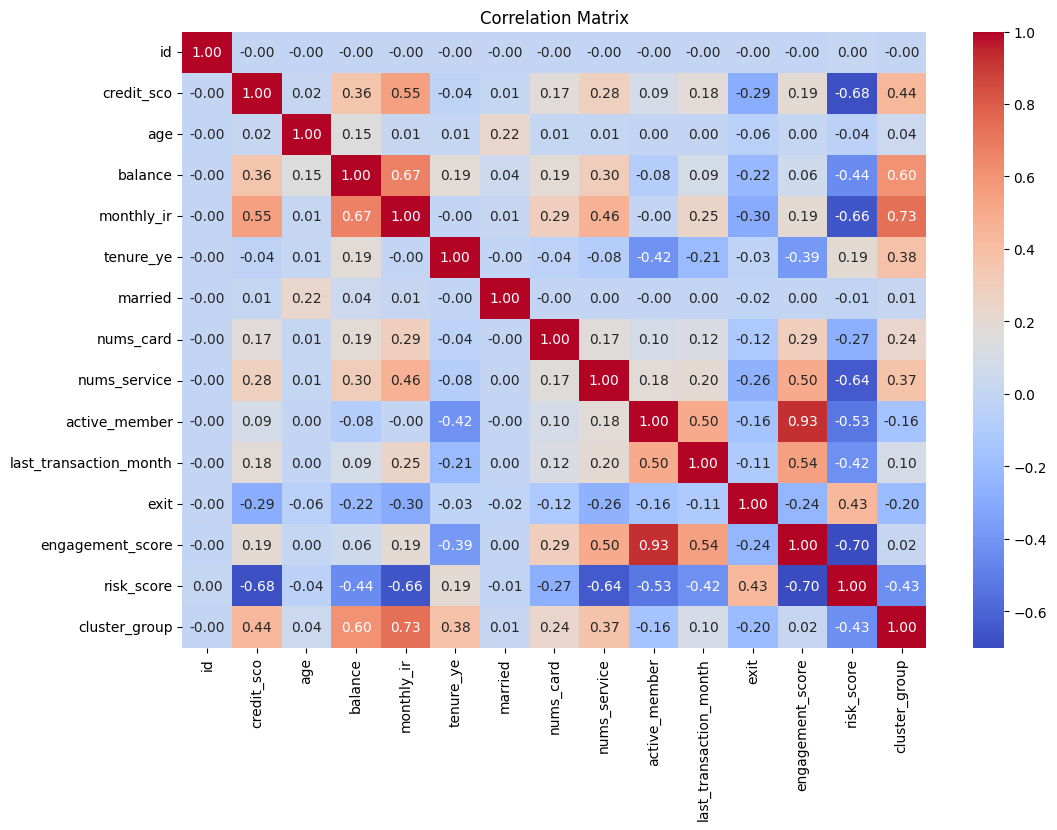

In [16]:
# Correlation matrix
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

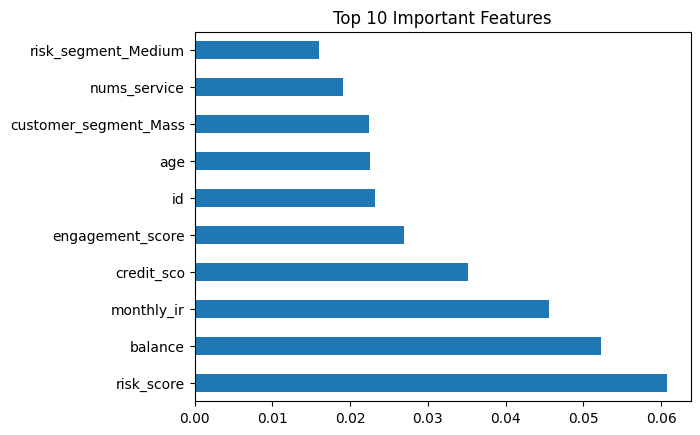

In [17]:
# Features Importance
from sklearn.ensemble import RandomForestClassifier

X = df.drop('exit', axis=1)
X = pd.get_dummies(X, drop_first=True)
y = df['exit']

model = RandomForestClassifier()
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()

## Preprocessing

In [18]:
# Các thư viện đã được import ở Cell đầu tiên

In [19]:
# ── Preprocessing ──────────────────────────────────────────────────────

# 1. Drop cột không dùng
#    - ID / PII: customer_id, full_name, address
#    - Date cols: created_date, last_active_date
#    - Potential leakage: risk_score, risk_segment, cluster_group
DROP_COLS = ['customer_id', 'full_name', 'address',
             'created_date', 'last_active_date',
             'risk_score', 'risk_segment', 'cluster_group']

data = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

# 2. Tách features và target
TARGET = 'exit'
X = data.drop(columns=[TARGET])
y = data[TARGET].astype(int)

# 3. Phân loại cột
bool_cols = X.select_dtypes(include='bool').columns.tolist()
for col in bool_cols:
    X[col] = X[col].astype(int)

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()

print(f'Numerical features ({len(num_cols)}): {num_cols}')
print(f'Categorical features ({len(cat_cols)}): {cat_cols}')
print(f'Target distribution:\n{y.value_counts()}')

# 4. Chia 3 tập: Train 70% | Val 15% | Test 15%
#    - stratify=y đảm bảo tỷ lệ churn giữ nguyên ở cả 3 tập
#    - SMOTE chỉ apply trên train — không bị leakage sang val/test
RANDOM_STATE = 42
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f'\nTrain: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')
print(f'Train churn rate: {y_train.mean():.2%}')
print(f'Val   churn rate: {y_val.mean():.2%}')
print(f'Test  churn rate: {y_test.mean():.2%}')

# 5. Preprocessor (Pipeline — fit chỉ trên train, transform val/test)
num_pipe = SklearnPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
cat_pipe = SklearnPipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols),
])

print('\nPreprocessor sẵn sàng.')


Numerical features (12): ['id', 'credit_sco', 'age', 'balance', 'monthly_ir', 'tenure_ye', 'married', 'nums_card', 'nums_service', 'active_member', 'last_transaction_month', 'engagement_score']
Categorical features (6): ['gender', 'occupation', 'origin_province', 'customer_segment', 'loyalty_level', 'digital_behavior']
Target distribution:
exit
0    65600
1    14400
Name: count, dtype: int64

Train: 56000 | Val: 12000 | Test: 12000
Train churn rate: 18.00%
Val   churn rate: 18.00%
Test  churn rate: 18.00%

Preprocessor sẵn sàng.


## Modeling

Ba pipeline sẽ được chạy và so sánh:
1. **Pipeline 1 — Baseline**: Không dùng SMOTE, không Threshold Tuning (dùng threshold mặc định 0.5)
2. **Pipeline 2 — SMOTE**: Chỉ dùng SMOTE để xử lý mất cân bằng, threshold mặc định 0.5
3. **Pipeline 3 — SMOTE + Threshold Tuning**: Kết hợp SMOTE và Threshold Tuning trên Validation Set


In [20]:
# Thư viện modeling đã được import ở Cell đầu tiên

In [21]:
# ── Định nghĩa base models (dùng chung cho cả 3 pipeline) ─────────────────────
# Lưu ý:
#  - KHÔNG dùng class_weight để tránh can thiệp vào cả 3 pipeline
#  - SMOTE chỉ apply trên train set (trong ImbPipeline) — không gây leakage
#  - Naive Bayes không hỗ trợ class_weight — dùng SMOTE (pipeline 2 & 3)

def build_base_models():
    return {
        'Logistic Regression': LogisticRegression(
            max_iter=1000, random_state=RANDOM_STATE
        ),
        'Decision Tree': DecisionTreeClassifier(
            max_depth=5, random_state=RANDOM_STATE
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1
        ),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=100, learning_rate=0.1,
            eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
        ),
        'Naive Bayes': GaussianNB(),
    }

THRESHOLDS = np.linspace(0.05, 0.95, 181)

print('Base models đã được định nghĩa.')
print('Sẵn sàng chạy 3 pipeline: Baseline | SMOTE | SMOTE + Threshold Tuning')


Base models đã được định nghĩa.
Sẵn sàng chạy 3 pipeline: Baseline | SMOTE | SMOTE + Threshold Tuning


---
## Pipeline 1 — Baseline (Không SMOTE, Không Threshold Tuning)

- Không dùng bất kỳ kỹ thuật xử lý mất cân bằng nào
- Threshold mặc định = **0.5**
- Đây là baseline để so sánh với 2 pipeline còn lại


[P1] Training Logistic Regression...
  Threshold: 0.50 (mặc định)
  Precision_Churn : 0.6272
  Recall_Churn    : 0.3412
  F1_Churn        : 0.4420
  ROC_AUC         : 0.8578



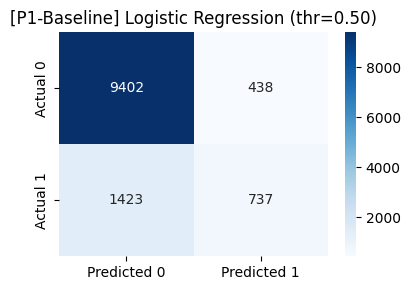

[P1] Training Decision Tree...
  Threshold: 0.50 (mặc định)
  Precision_Churn : 0.5712
  Recall_Churn    : 0.3065
  F1_Churn        : 0.3989
  ROC_AUC         : 0.8380



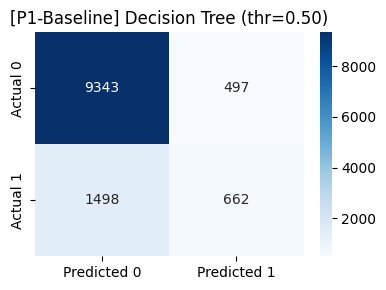

[P1] Training Random Forest...
  Threshold: 0.50 (mặc định)
  Precision_Churn : 0.5883
  Recall_Churn    : 0.3176
  F1_Churn        : 0.4125
  ROC_AUC         : 0.8491



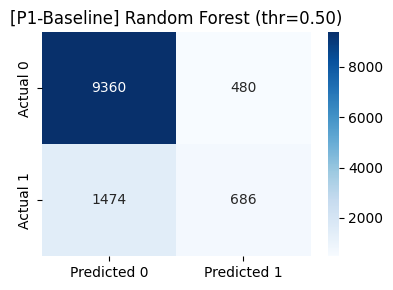

[P1] Training XGBoost...
  Threshold: 0.50 (mặc định)
  Precision_Churn : 0.6154
  Recall_Churn    : 0.3148
  F1_Churn        : 0.4165
  ROC_AUC         : 0.8564



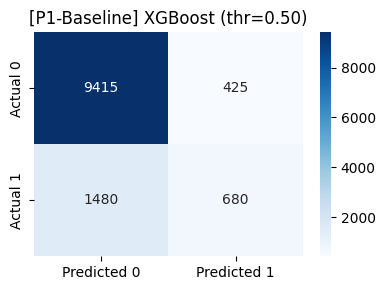

[P1] Training Naive Bayes...
  Threshold: 0.50 (mặc định)
  Precision_Churn : 0.3136
  Recall_Churn    : 0.9227
  F1_Churn        : 0.4681
  ROC_AUC         : 0.8304



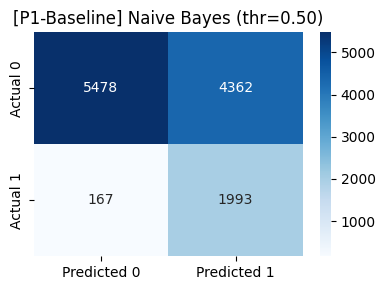

In [22]:
# ── Pipeline 1: Baseline — SklearnPipeline (preprocess → model) ───────────────
# Không SMOTE, không Threshold Tuning, threshold mặc định = 0.5

results_p1 = []
trained_p1 = {}

for name, model in build_base_models().items():
    pipe = SklearnPipeline([
        ('preprocess', preprocessor),
        ('model',      model),
    ])
    print(f'[P1] Training {name}...')
    pipe.fit(X_train, y_train)
    trained_p1[name] = pipe

    # Threshold mặc định 0.5
    test_proba = pipe.predict_proba(X_test)[:, 1]
    y_pred = (test_proba >= 0.5).astype(int)

    acc   = accuracy_score(y_test, y_pred)
    prec  = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec   = recall_score(y_test, y_pred,    pos_label=1, zero_division=0)
    f1_ch = f1_score(y_test, y_pred,         pos_label=1, zero_division=0)
    f1_ma = f1_score(y_test, y_pred,         average='macro',  zero_division=0)
    roc   = roc_auc_score(y_test, test_proba)

    results_p1.append({
        'Model':           name,
        'Threshold':       0.500,
        'Accuracy':        round(acc,   4),
        'Precision_Churn': round(prec,  4),
        'Recall_Churn':    round(rec,   4),
        'F1_Churn':        round(f1_ch, 4),
        'F1_Macro':        round(f1_ma, 4),
        'ROC_AUC':         round(roc,   4),
    })

    print(f'  Threshold: 0.50 (mặc định)')
    print(f'  Precision_Churn : {prec:.4f}')
    print(f'  Recall_Churn    : {rec:.4f}')
    print(f'  F1_Churn        : {f1_ch:.4f}')
    print(f'  ROC_AUC         : {roc:.4f}')
    print()

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0','Predicted 1'],
                yticklabels=['Actual 0','Actual 1'])
    plt.title(f'[P1-Baseline] {name} (thr=0.50)')
    plt.tight_layout()
    plt.show()


In [23]:
# ── Pipeline 1: Bảng kết quả ──────────────────────────────────────────────────
df_p1 = pd.DataFrame(results_p1).sort_values('F1_Churn', ascending=False)
print('=== PIPELINE 1 — BASELINE (không SMOTE, không Threshold Tuning) ===')
print(df_p1.to_string(index=False))
best_p1 = df_p1.iloc[0]
print(f"\n=> Best [P1]: {best_p1['Model']} | F1_Churn={best_p1['F1_Churn']:.4f} | ROC_AUC={best_p1['ROC_AUC']:.4f}")


=== PIPELINE 1 — BASELINE (không SMOTE, không Threshold Tuning) ===
              Model  Threshold  Accuracy  Precision_Churn  Recall_Churn  F1_Churn  F1_Macro  ROC_AUC
        Naive Bayes        0.5    0.6226           0.3136        0.9227    0.4681    0.5878   0.8304
Logistic Regression        0.5    0.8449           0.6272        0.3412    0.4420    0.6760   0.8578
            XGBoost        0.5    0.8413           0.6154        0.3148    0.4165    0.6623   0.8564
      Random Forest        0.5    0.8372           0.5883        0.3176    0.4125    0.6590   0.8491
      Decision Tree        0.5    0.8337           0.5712        0.3065    0.3989    0.6512   0.8380

=> Best [P1]: Naive Bayes | F1_Churn=0.4681 | ROC_AUC=0.8304


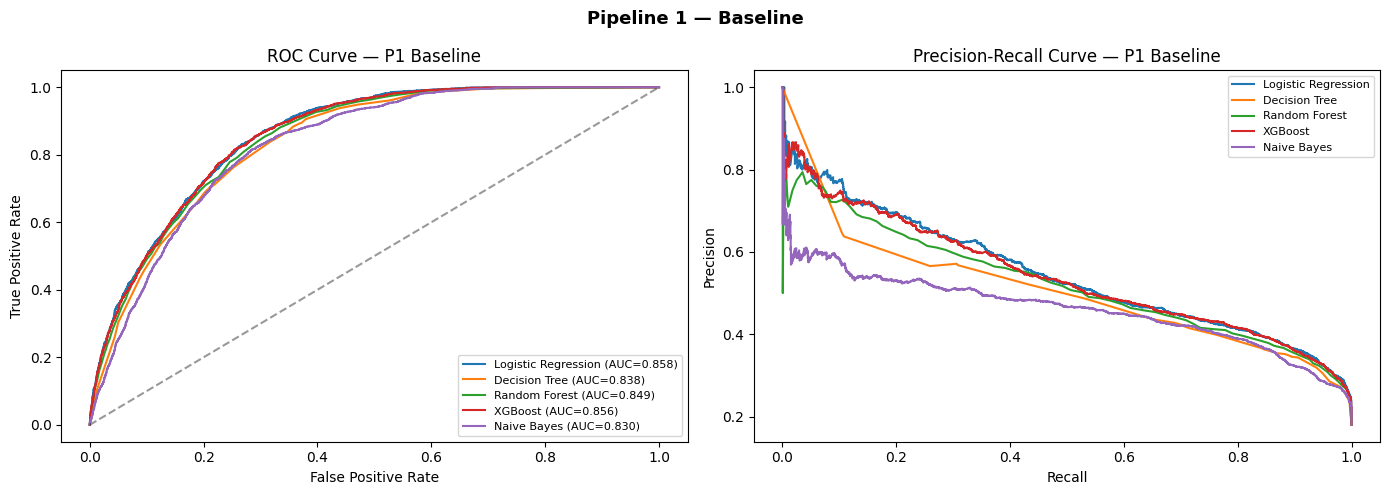

In [24]:
# ── Pipeline 1: ROC & PR Curve ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pipeline 1 — Baseline', fontsize=13, fontweight='bold')

for name, pipe in trained_p1.items():
    test_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, test_proba)
    auc_val = roc_auc_score(y_test, test_proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')
    prec_arr, rec_arr, _ = precision_recall_curve(y_test, test_proba)
    axes[1].plot(rec_arr, prec_arr, label=name)

axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — P1 Baseline'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — P1 Baseline'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


---
## Pipeline 2 — SMOTE (Chỉ SMOTE, Không Threshold Tuning)

- Dùng **SMOTE** để oversample minority class (churn) trên tập train
- SMOTE chỉ apply trong pipeline trên train set — **không gây data leakage**
- Threshold mặc định = **0.5**


[P2] Training Logistic Regression...
  Threshold: 0.50 (mặc định)
  Precision_Churn : 0.3963
  Recall_Churn    : 0.8380
  F1_Churn        : 0.5381
  ROC_AUC         : 0.8574



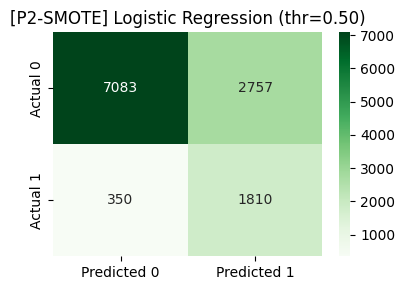

[P2] Training Decision Tree...
  Threshold: 0.50 (mặc định)
  Precision_Churn : 0.3660
  Recall_Churn    : 0.8222
  F1_Churn        : 0.5066
  ROC_AUC         : 0.8220



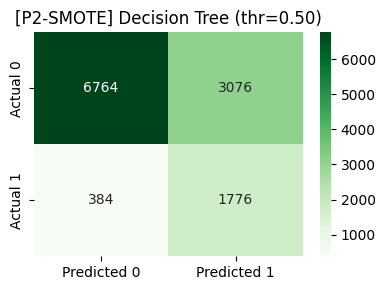

[P2] Training Random Forest...
  Threshold: 0.50 (mặc định)
  Precision_Churn : 0.5022
  Recall_Churn    : 0.4755
  F1_Churn        : 0.4885
  ROC_AUC         : 0.8463



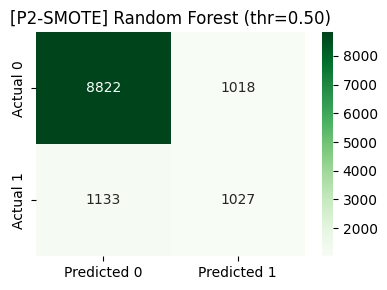

[P2] Training XGBoost...
  Threshold: 0.50 (mặc định)
  Precision_Churn : 0.5092
  Recall_Churn    : 0.5019
  F1_Churn        : 0.5055
  ROC_AUC         : 0.8522



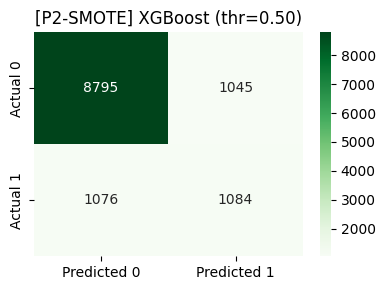

[P2] Training Naive Bayes...
  Threshold: 0.50 (mặc định)
  Precision_Churn : 0.3120
  Recall_Churn    : 0.9241
  F1_Churn        : 0.4665
  ROC_AUC         : 0.8289



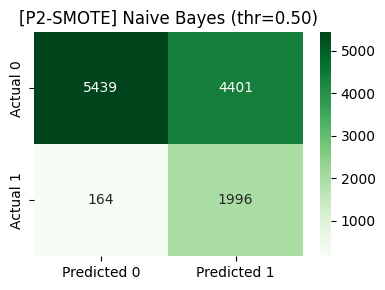

In [25]:
# ── Pipeline 2: SMOTE Only — ImbPipeline (preprocess → SMOTE → model) ─────────
# Không Threshold Tuning, threshold mặc định = 0.5

results_p2 = []
trained_p2 = {}

for name, model in build_base_models().items():
    pipe = ImbPipeline([
        ('preprocess', preprocessor),
        ('smote',      SMOTE(random_state=RANDOM_STATE)),
        ('model',      model),
    ])
    print(f'[P2] Training {name}...')
    pipe.fit(X_train, y_train)
    trained_p2[name] = pipe

    # Threshold mặc định 0.5
    test_proba = pipe.predict_proba(X_test)[:, 1]
    y_pred = (test_proba >= 0.5).astype(int)

    acc   = accuracy_score(y_test, y_pred)
    prec  = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec   = recall_score(y_test, y_pred,    pos_label=1, zero_division=0)
    f1_ch = f1_score(y_test, y_pred,         pos_label=1, zero_division=0)
    f1_ma = f1_score(y_test, y_pred,         average='macro',  zero_division=0)
    roc   = roc_auc_score(y_test, test_proba)

    results_p2.append({
        'Model':           name,
        'Threshold':       0.500,
        'Accuracy':        round(acc,   4),
        'Precision_Churn': round(prec,  4),
        'Recall_Churn':    round(rec,   4),
        'F1_Churn':        round(f1_ch, 4),
        'F1_Macro':        round(f1_ma, 4),
        'ROC_AUC':         round(roc,   4),
    })

    print(f'  Threshold: 0.50 (mặc định)')
    print(f'  Precision_Churn : {prec:.4f}')
    print(f'  Recall_Churn    : {rec:.4f}')
    print(f'  F1_Churn        : {f1_ch:.4f}')
    print(f'  ROC_AUC         : {roc:.4f}')
    print()

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Predicted 0','Predicted 1'],
                yticklabels=['Actual 0','Actual 1'])
    plt.title(f'[P2-SMOTE] {name} (thr=0.50)')
    plt.tight_layout()
    plt.show()


In [26]:
# ── Pipeline 2: Bảng kết quả ──────────────────────────────────────────────────
df_p2 = pd.DataFrame(results_p2).sort_values('F1_Churn', ascending=False)
print('=== PIPELINE 2 — SMOTE ONLY (không Threshold Tuning) ===')
print(df_p2.to_string(index=False))
best_p2 = df_p2.iloc[0]
print(f"\n=> Best [P2]: {best_p2['Model']} | F1_Churn={best_p2['F1_Churn']:.4f} | ROC_AUC={best_p2['ROC_AUC']:.4f}")


=== PIPELINE 2 — SMOTE ONLY (không Threshold Tuning) ===
              Model  Threshold  Accuracy  Precision_Churn  Recall_Churn  F1_Churn  F1_Macro  ROC_AUC
Logistic Regression        0.5    0.7411           0.3963        0.8380    0.5381    0.6791   0.8574
      Decision Tree        0.5    0.7117           0.3660        0.8222    0.5066    0.6514   0.8220
            XGBoost        0.5    0.8233           0.5092        0.5019    0.5055    0.6989   0.8522
      Random Forest        0.5    0.8207           0.5022        0.4755    0.4885    0.6899   0.8463
        Naive Bayes        0.5    0.6196           0.3120        0.9241    0.4665    0.5855   0.8289

=> Best [P2]: Logistic Regression | F1_Churn=0.5381 | ROC_AUC=0.8574


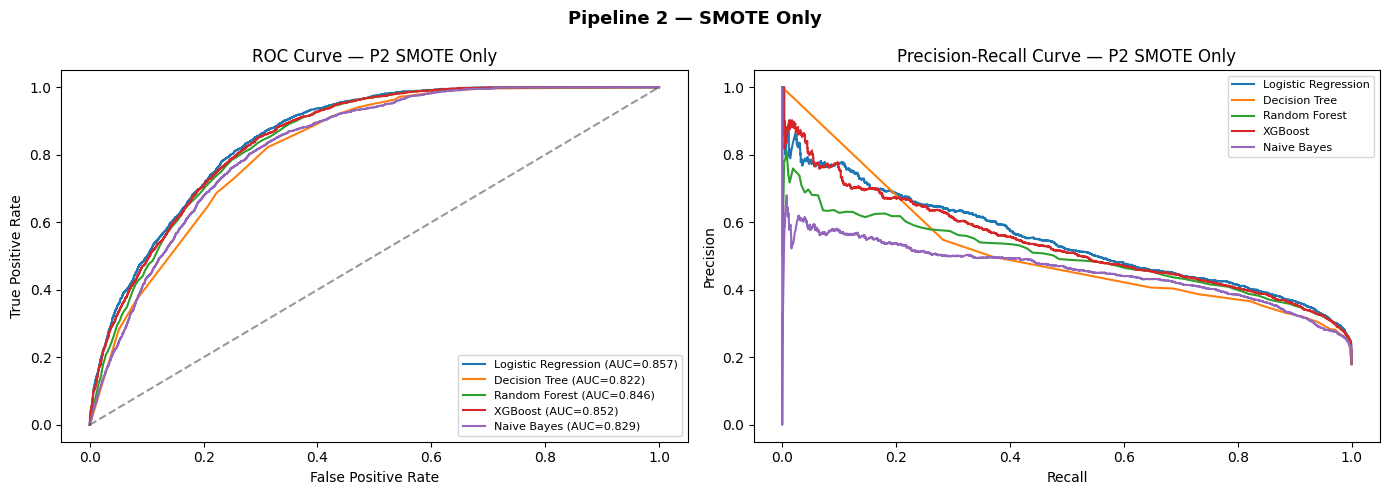

In [27]:
# ── Pipeline 2: ROC & PR Curve ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pipeline 2 — SMOTE Only', fontsize=13, fontweight='bold')

for name, pipe in trained_p2.items():
    test_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, test_proba)
    auc_val = roc_auc_score(y_test, test_proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')
    prec_arr, rec_arr, _ = precision_recall_curve(y_test, test_proba)
    axes[1].plot(rec_arr, prec_arr, label=name)

axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — P2 SMOTE Only'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — P2 SMOTE Only'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


---
## Pipeline 3 — SMOTE + Threshold Tuning

- Dùng **SMOTE** kết hợp với **Threshold Tuning** trên Validation Set
- Quy trình đúng:
  1. Fit pipeline trên `X_train` (SMOTE chỉ thấy train)
  2. Tìm threshold tối ưu **F1_Churn** trên `X_val`
  3. Đánh giá cuối cùng trên `X_test` (chỉ dùng **1 lần**)


[P3] Training Logistic Regression...
  Threshold tối ưu (val): 0.62
  Precision_Churn : 0.4404
  Recall_Churn    : 0.7065
  F1_Churn        : 0.5426
  ROC_AUC         : 0.8574



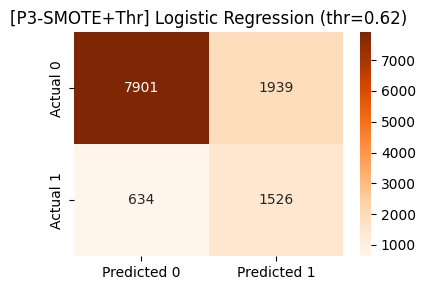

[P3] Training Decision Tree...
  Threshold tối ưu (val): 0.57
  Precision_Churn : 0.4037
  Recall_Churn    : 0.6870
  F1_Churn        : 0.5086
  ROC_AUC         : 0.8220



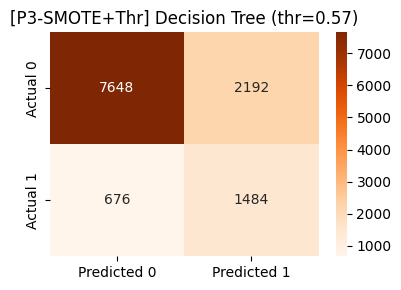

[P3] Training Random Forest...
  Threshold tối ưu (val): 0.36
  Precision_Churn : 0.4323
  Recall_Churn    : 0.7060
  F1_Churn        : 0.5362
  ROC_AUC         : 0.8463



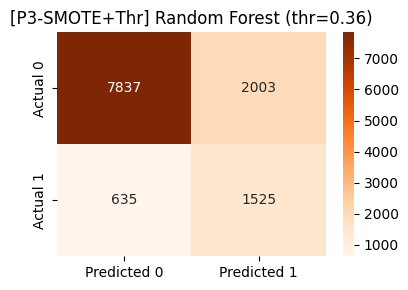

[P3] Training XGBoost...
  Threshold tối ưu (val): 0.40
  Precision_Churn : 0.4560
  Recall_Churn    : 0.6435
  F1_Churn        : 0.5338
  ROC_AUC         : 0.8522



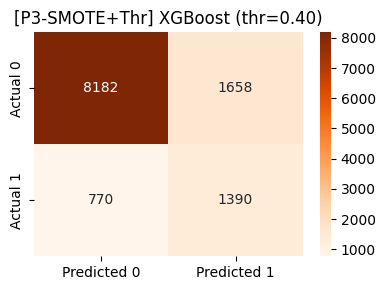

[P3] Training Naive Bayes...
  Threshold tối ưu (val): 0.94
  Precision_Churn : 0.3162
  Recall_Churn    : 0.9194
  F1_Churn        : 0.4706
  ROC_AUC         : 0.8289



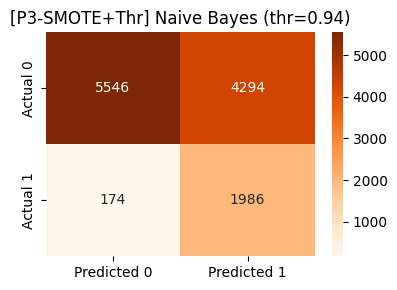

In [28]:
# ── Pipeline 3: SMOTE + Threshold Tuning ──────────────────────────────────────
# ImbPipeline: preprocess → SMOTE → model
# Threshold tìm tối ưu F1_Churn trên Validation Set

results_p3 = []
trained_p3 = {}
best_thresholds_p3 = {}

for name, model in build_base_models().items():
    pipe = ImbPipeline([
        ('preprocess', preprocessor),
        ('smote',      SMOTE(random_state=RANDOM_STATE)),
        ('model',      model),
    ])
    print(f'[P3] Training {name}...')
    pipe.fit(X_train, y_train)
    trained_p3[name] = pipe

    # Tìm threshold tối ưu trên VAL set
    val_proba = pipe.predict_proba(X_val)[:, 1]
    best_t = max(
        THRESHOLDS,
        key=lambda t: f1_score(
            y_val, (val_proba >= t).astype(int),
            pos_label=1, zero_division=0
        )
    )
    best_thresholds_p3[name] = best_t

    # Đánh giá trên TEST set với threshold tối ưu
    test_proba = pipe.predict_proba(X_test)[:, 1]
    y_pred = (test_proba >= best_t).astype(int)

    acc   = accuracy_score(y_test, y_pred)
    prec  = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec   = recall_score(y_test, y_pred,    pos_label=1, zero_division=0)
    f1_ch = f1_score(y_test, y_pred,         pos_label=1, zero_division=0)
    f1_ma = f1_score(y_test, y_pred,         average='macro',  zero_division=0)
    roc   = roc_auc_score(y_test, test_proba)

    results_p3.append({
        'Model':           name,
        'Threshold':       round(best_t, 3),
        'Accuracy':        round(acc,   4),
        'Precision_Churn': round(prec,  4),
        'Recall_Churn':    round(rec,   4),
        'F1_Churn':        round(f1_ch, 4),
        'F1_Macro':        round(f1_ma, 4),
        'ROC_AUC':         round(roc,   4),
    })

    print(f'  Threshold tối ưu (val): {best_t:.2f}')
    print(f'  Precision_Churn : {prec:.4f}')
    print(f'  Recall_Churn    : {rec:.4f}')
    print(f'  F1_Churn        : {f1_ch:.4f}')
    print(f'  ROC_AUC         : {roc:.4f}')
    print()

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['Predicted 0','Predicted 1'],
                yticklabels=['Actual 0','Actual 1'])
    plt.title(f'[P3-SMOTE+Thr] {name} (thr={best_t:.2f})')
    plt.tight_layout()
    plt.show()


In [29]:
# ── Pipeline 3: Bảng kết quả ──────────────────────────────────────────────────
df_p3 = pd.DataFrame(results_p3).sort_values('F1_Churn', ascending=False)
print('=== PIPELINE 3 — SMOTE + THRESHOLD TUNING ===')
print(df_p3.to_string(index=False))
best_p3 = df_p3.iloc[0]
print(f"\n=> Best [P3]: {best_p3['Model']} | F1_Churn={best_p3['F1_Churn']:.4f} | ROC_AUC={best_p3['ROC_AUC']:.4f}")


=== PIPELINE 3 — SMOTE + THRESHOLD TUNING ===
              Model  Threshold  Accuracy  Precision_Churn  Recall_Churn  F1_Churn  F1_Macro  ROC_AUC
Logistic Regression      0.620    0.7856           0.4404        0.7065    0.5426    0.7013   0.8574
      Random Forest      0.365    0.7802           0.4323        0.7060    0.5362    0.6961   0.8463
            XGBoost      0.405    0.7977           0.4560        0.6435    0.5338    0.7023   0.8522
      Decision Tree      0.570    0.7610           0.4037        0.6870    0.5086    0.6753   0.8220
        Naive Bayes      0.940    0.6277           0.3162        0.9194    0.4706    0.5917   0.8289

=> Best [P3]: Logistic Regression | F1_Churn=0.5426 | ROC_AUC=0.8574


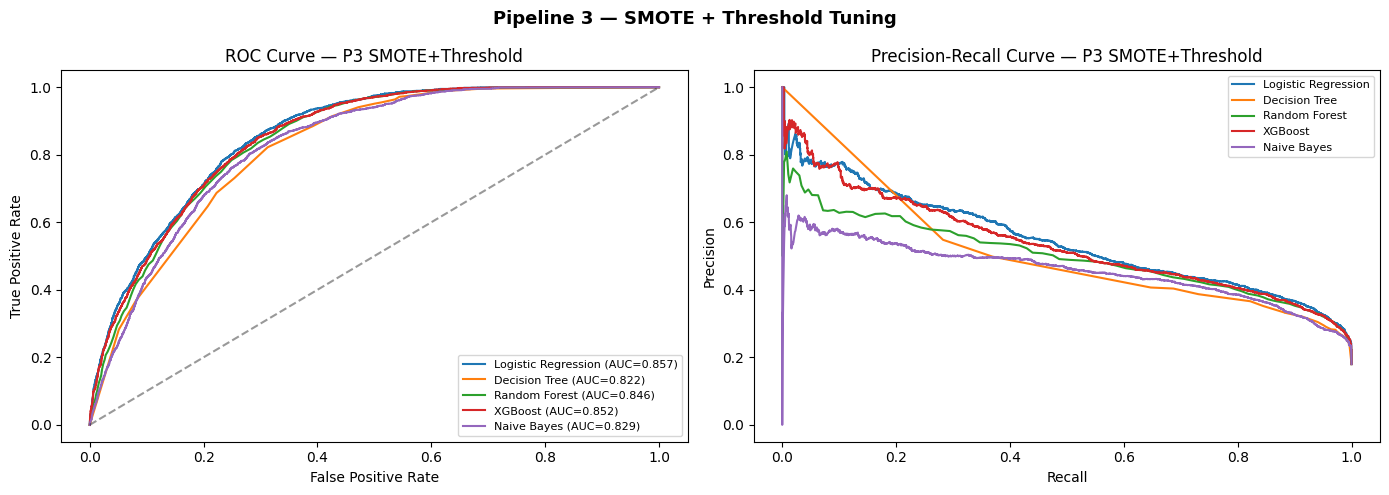

In [30]:
# ── Pipeline 3: ROC & PR Curve ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pipeline 3 — SMOTE + Threshold Tuning', fontsize=13, fontweight='bold')

for name, pipe in trained_p3.items():
    test_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, test_proba)
    auc_val = roc_auc_score(y_test, test_proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')
    prec_arr, rec_arr, _ = precision_recall_curve(y_test, test_proba)
    axes[1].plot(rec_arr, prec_arr, label=name)

axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — P3 SMOTE+Threshold'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — P3 SMOTE+Threshold'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


---
## So Sánh 3 Pipeline

So sánh toàn diện kết quả của cả 3 pipeline theo từng model và theo metric.


In [31]:
# ── Bảng so sánh tổng hợp 3 pipeline ─────────────────────────────────────────
df_p1_tag = df_p1.copy(); df_p1_tag.insert(0, 'Pipeline', 'P1-Baseline')
df_p2_tag = df_p2.copy(); df_p2_tag.insert(0, 'Pipeline', 'P2-SMOTE')
df_p3_tag = df_p3.copy(); df_p3_tag.insert(0, 'Pipeline', 'P3-SMOTE+Thr')

df_all = pd.concat([df_p1_tag, df_p2_tag, df_p3_tag], ignore_index=True)

print('=' * 80)
print('BẢNG SO SÁNH TỔNG HỢP — 3 PIPELINE (sắp xếp theo F1_Churn)')
print('=' * 80)
print(df_all.sort_values(['Model', 'Pipeline']).to_string(index=False))


BẢNG SO SÁNH TỔNG HỢP — 3 PIPELINE (sắp xếp theo F1_Churn)
    Pipeline               Model  Threshold  Accuracy  Precision_Churn  Recall_Churn  F1_Churn  F1_Macro  ROC_AUC
 P1-Baseline       Decision Tree      0.500    0.8337           0.5712        0.3065    0.3989    0.6512   0.8380
    P2-SMOTE       Decision Tree      0.500    0.7117           0.3660        0.8222    0.5066    0.6514   0.8220
P3-SMOTE+Thr       Decision Tree      0.570    0.7610           0.4037        0.6870    0.5086    0.6753   0.8220
 P1-Baseline Logistic Regression      0.500    0.8449           0.6272        0.3412    0.4420    0.6760   0.8578
    P2-SMOTE Logistic Regression      0.500    0.7411           0.3963        0.8380    0.5381    0.6791   0.8574
P3-SMOTE+Thr Logistic Regression      0.620    0.7856           0.4404        0.7065    0.5426    0.7013   0.8574
 P1-Baseline         Naive Bayes      0.500    0.6226           0.3136        0.9227    0.4681    0.5878   0.8304
    P2-SMOTE         Naive Ba

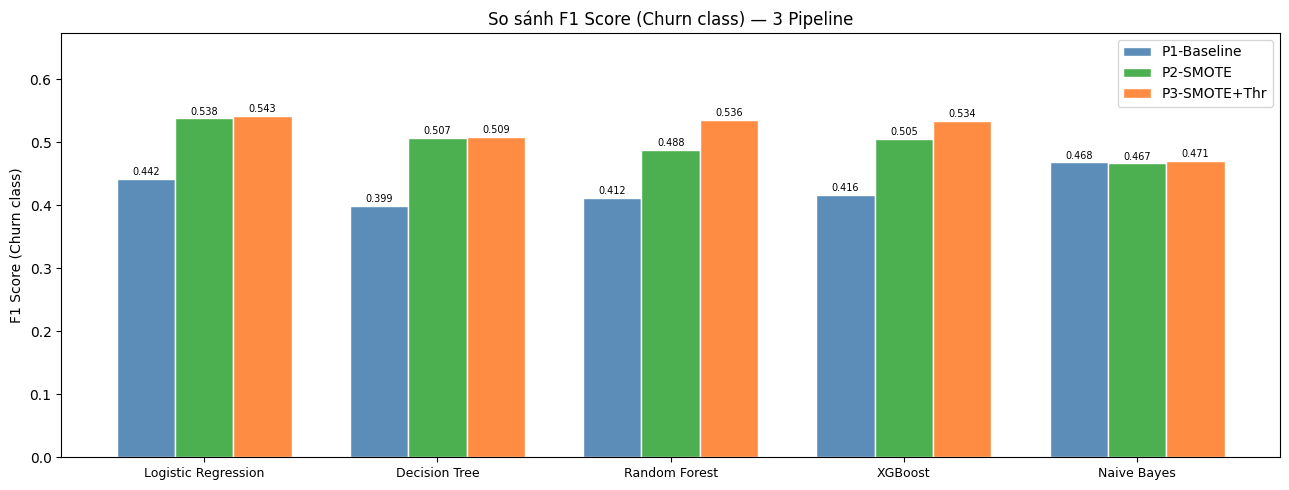

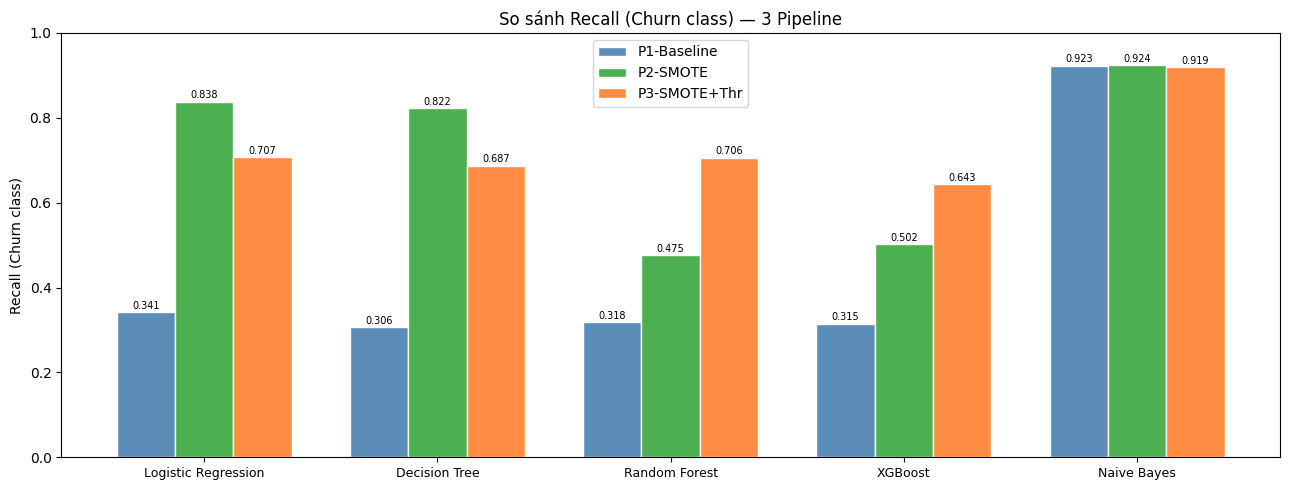

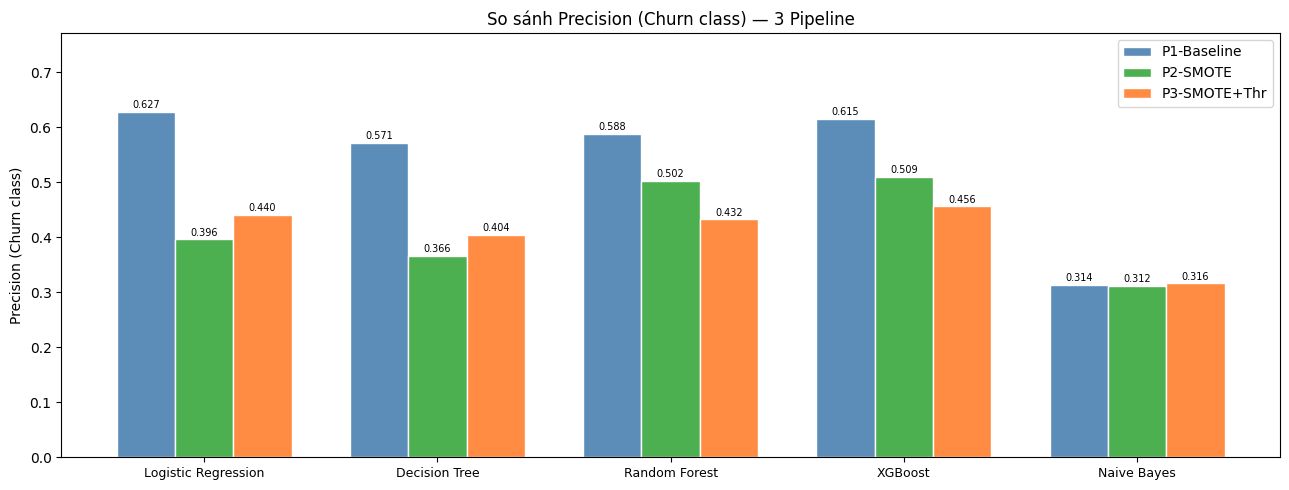

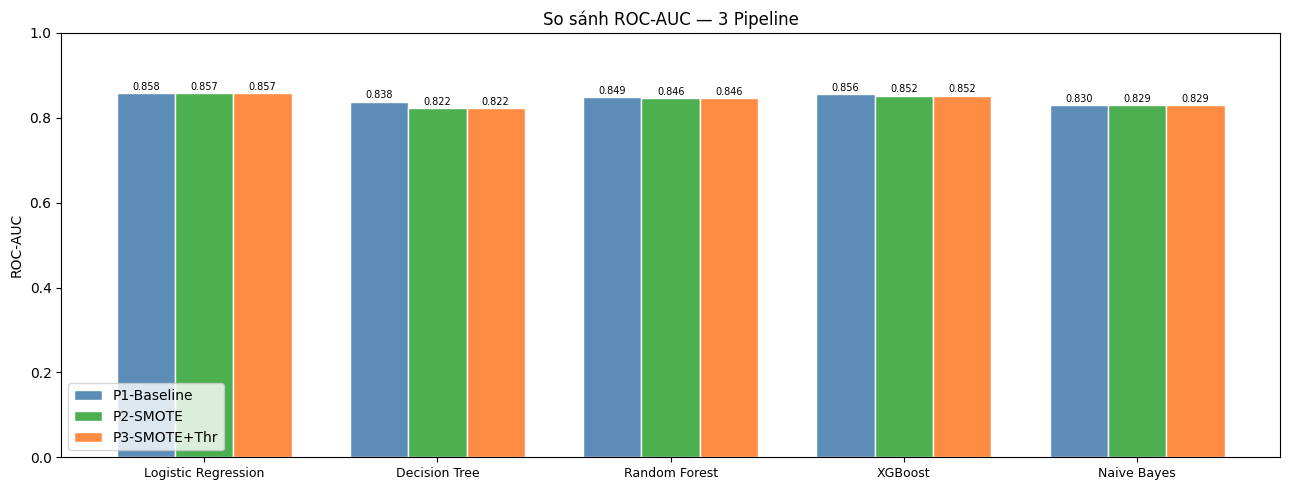

In [32]:
# ── Biểu đồ so sánh F1_Churn và ROC_AUC theo Pipeline × Model ────────────────
import matplotlib.pyplot as plt
import numpy as np

models_list = list(build_base_models().keys())
x = np.arange(len(models_list))
width = 0.25

metrics_to_plot = [
    ('F1_Churn',        'F1 Score (Churn class)'),
    ('Recall_Churn',    'Recall (Churn class)'),
    ('Precision_Churn', 'Precision (Churn class)'),
    ('ROC_AUC',         'ROC-AUC'),
]

for metric, ylabel in metrics_to_plot:
    fig, ax = plt.subplots(figsize=(13, 5))

    vals_p1 = [df_p1.set_index('Model').loc[m, metric] for m in models_list]
    vals_p2 = [df_p2.set_index('Model').loc[m, metric] for m in models_list]
    vals_p3 = [df_p3.set_index('Model').loc[m, metric] for m in models_list]

    b1 = ax.bar(x - width, vals_p1, width, label='P1-Baseline',     color='#5B8DB8', edgecolor='white')
    b2 = ax.bar(x,         vals_p2, width, label='P2-SMOTE',        color='#4CAF50', edgecolor='white')
    b3 = ax.bar(x + width, vals_p3, width, label='P3-SMOTE+Thr',    color='#FF8C42', edgecolor='white')

    for bars in [b1, b2, b3]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(models_list, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(f'So sánh {ylabel} — 3 Pipeline')
    ax.legend()
    ax.set_ylim(0, min(1.0, max(vals_p1 + vals_p2 + vals_p3) * 1.15 + 0.05))
    plt.tight_layout()
    plt.show()


In [33]:
# ── Bảng best model từng pipeline và khuyến nghị ──────────────────────────────
print('\n' + '=' * 65)
print('BEST MODEL THEO TỪNG PIPELINE (theo F1_Churn)')
print('=' * 65)

for label, df_px in [('P1-Baseline', df_p1), ('P2-SMOTE', df_p2), ('P3-SMOTE+Thr', df_p3)]:
    row = df_px.sort_values('F1_Churn', ascending=False).iloc[0]
    thr_label = f"thr={row['Threshold']:.3f}"
    print(f"  [{label}]  Best: {row['Model']:<22} | F1_Churn={row['F1_Churn']:.4f} "
          f"| Recall={row['Recall_Churn']:.4f} | ROC_AUC={row['ROC_AUC']:.4f} | {thr_label}")

# Tổng best theo F1_Churn
overall_best = df_all.sort_values('F1_Churn', ascending=False).iloc[0]
print()
print(f"=> OVERALL BEST: [{overall_best['Pipeline']}] {overall_best['Model']} "
      f"| F1_Churn={overall_best['F1_Churn']:.4f} | ROC_AUC={overall_best['ROC_AUC']:.4f}")

# Tổng best theo Recall
best_recall_all = df_all.sort_values('Recall_Churn', ascending=False).iloc[0]
print(f"=> BEST RECALL : [{best_recall_all['Pipeline']}] {best_recall_all['Model']} "
      f"| Recall={best_recall_all['Recall_Churn']:.4f}")



BEST MODEL THEO TỪNG PIPELINE (theo F1_Churn)
  [P1-Baseline]  Best: Naive Bayes            | F1_Churn=0.4681 | Recall=0.9227 | ROC_AUC=0.8304 | thr=0.500
  [P2-SMOTE]  Best: Logistic Regression    | F1_Churn=0.5381 | Recall=0.8380 | ROC_AUC=0.8574 | thr=0.500
  [P3-SMOTE+Thr]  Best: Logistic Regression    | F1_Churn=0.5426 | Recall=0.7065 | ROC_AUC=0.8574 | thr=0.620

=> OVERALL BEST: [P3-SMOTE+Thr] Logistic Regression | F1_Churn=0.5426 | ROC_AUC=0.8574
=> BEST RECALL : [P2-SMOTE] Naive Bayes | Recall=0.9241


## Feature Importance & SHAP (từ Pipeline 3 — SMOTE + Threshold Tuning)

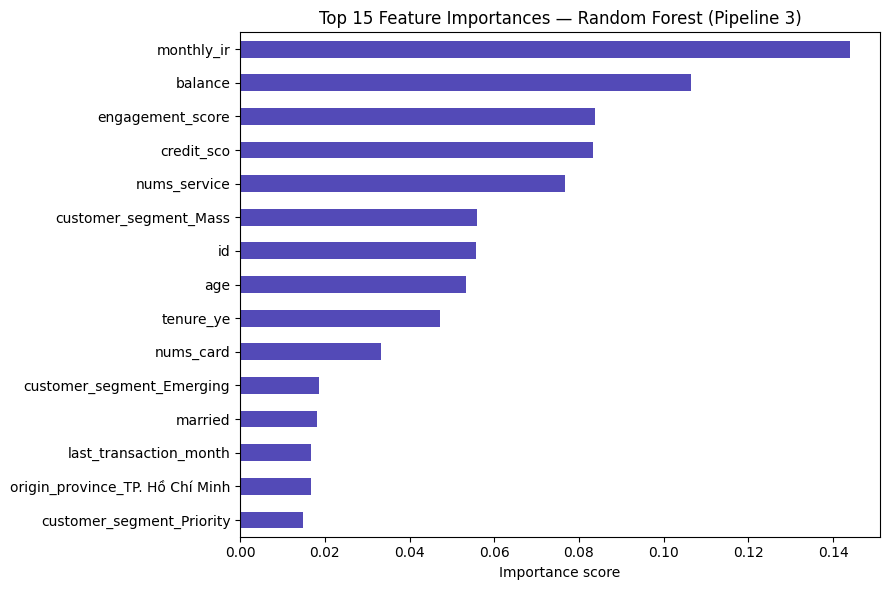

In [34]:
# ── Feature Importance (Random Forest — Pipeline 3) ───────────────────────────
rf_pipe  = trained_p3['Random Forest']
rf_model = rf_pipe.named_steps['model']
rf_pre   = rf_pipe.named_steps['preprocess']

num_names  = num_cols
cat_names  = rf_pre.named_transformers_['cat']['ohe'].get_feature_names_out(cat_cols).tolist()
feature_names = num_names + cat_names

importances = pd.Series(rf_model.feature_importances_, index=feature_names)
top15 = importances.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
top15.plot(kind='barh', ax=ax, color='#534AB7')
ax.set_title('Top 15 Feature Importances — Random Forest (Pipeline 3)')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.show()


## Giải thích mô hình bằng SHAP

SHAP giúp giải thích từng dự đoán: feature nào đẩy khách hàng về phía churn hoặc không churn.


Chạy SHAP với: XGBoost (Pipeline 3 — SMOTE + Threshold Tuning)

SHAP Summary Plot:


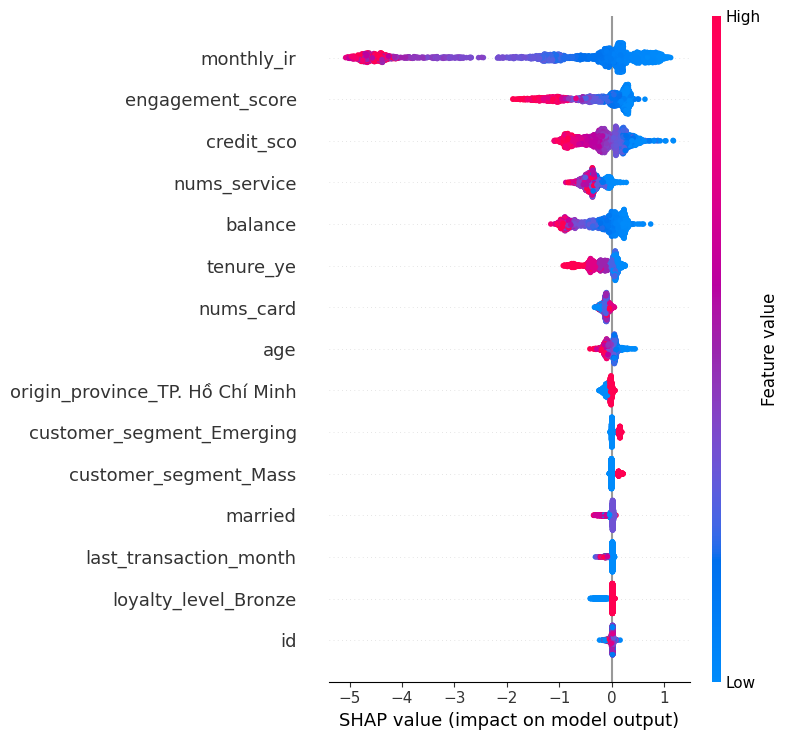


SHAP Bar Plot (mean |SHAP|):


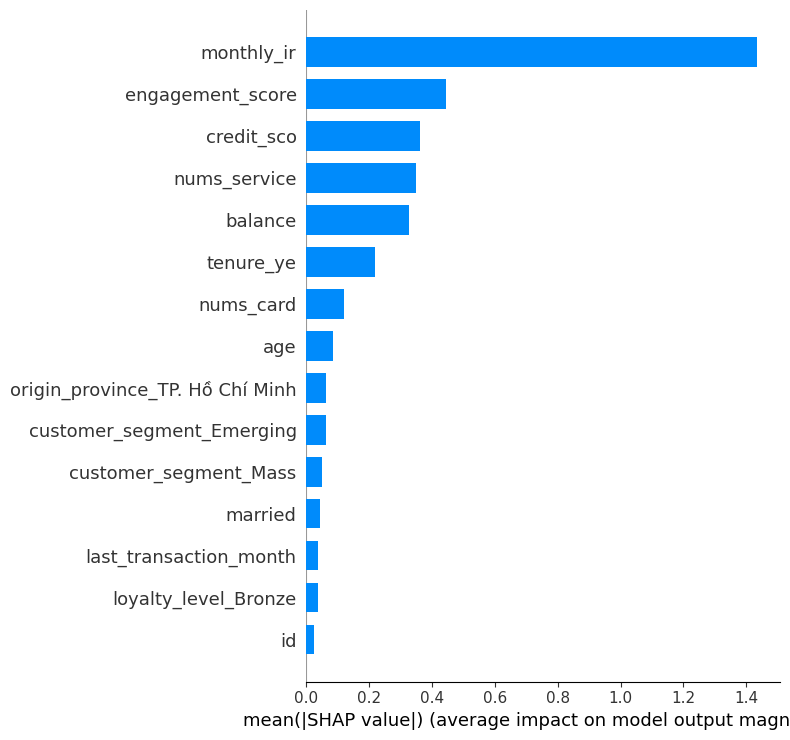


SHAP Waterfall Plot (khách hàng đầu tiên):


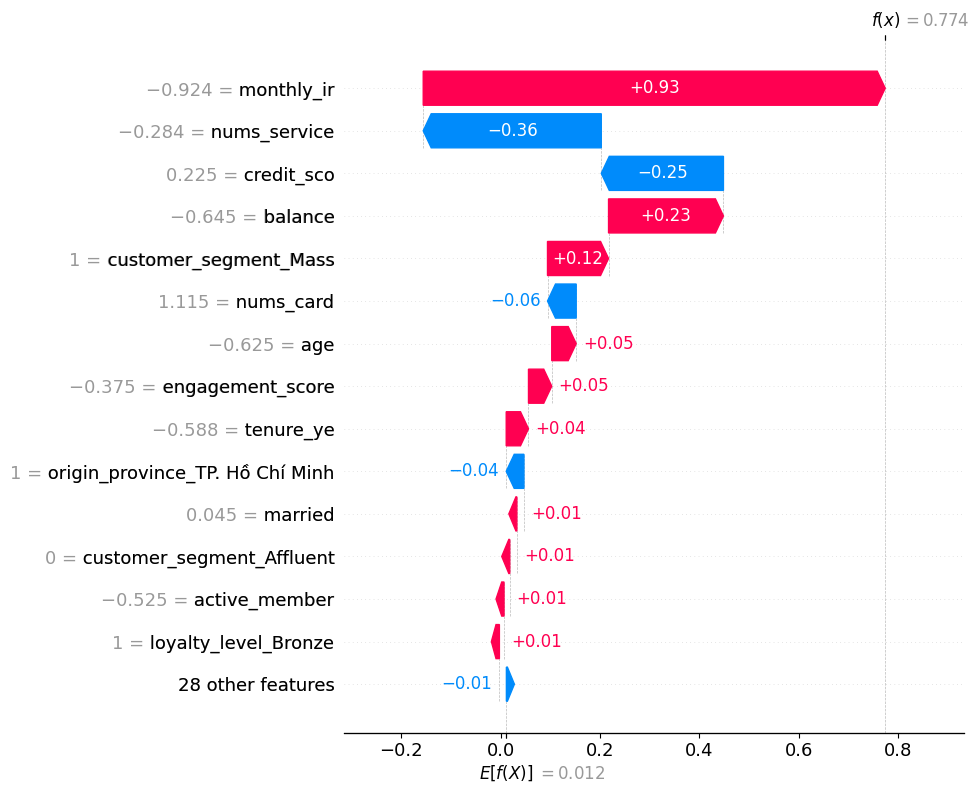

In [35]:
# ── SHAP Explanation (từ Pipeline 3) ──────────────────────────────────────────
if SHAP_OK:
    TREE_MODELS = ['XGBoost', 'Random Forest', 'Decision Tree']
    shap_name = next((m for m in TREE_MODELS if m in trained_p3), None)

    if shap_name:
        print(f'Chạy SHAP với: {shap_name} (Pipeline 3 — SMOTE + Threshold Tuning)')
        shap_pipe  = trained_p3[shap_name]
        shap_pre   = shap_pipe.named_steps['preprocess']
        shap_model = shap_pipe.named_steps['model']

        X_test_t = shap_pre.transform(X_test)
        num_feat  = num_cols
        cat_feat  = shap_pre.named_transformers_['cat']['ohe'].get_feature_names_out(cat_cols).tolist()
        feat_names = num_feat + cat_feat

        rng = np.random.default_rng(42)
        idx = rng.choice(len(X_test_t), min(2000, len(X_test_t)), replace=False)
        X_shap = X_test_t[idx]

        explainer   = shap.TreeExplainer(shap_model)
        shap_values = explainer.shap_values(X_shap)

        sv = shap_values[1] if isinstance(shap_values, list) else shap_values

        print('\nSHAP Summary Plot:')
        shap.summary_plot(sv, X_shap, feature_names=feat_names, max_display=15)

        print('\nSHAP Bar Plot (mean |SHAP|):')
        shap.summary_plot(sv, X_shap, feature_names=feat_names,
                          plot_type='bar', max_display=15)

        ev = explainer.expected_value
        base_val = ev[1] if isinstance(ev, (list, np.ndarray)) else ev
        exp = shap.Explanation(values=sv[0], base_values=base_val,
                               data=X_shap[0], feature_names=feat_names)
        print('\nSHAP Waterfall Plot (khách hàng đầu tiên):')
        shap.plots.waterfall(exp, max_display=15)
    else:
        print('Không tìm thấy tree-based model.')
else:
    print('Bỏ qua SHAP — chưa cài thư viện.')


## Kết luận

### Tổng kết kết quả

> Bảng dưới được tạo tự động từ kết quả chạy thực tế của cả 3 pipeline.

*(Xem bảng `df_all` và biểu đồ so sánh ở phần "So Sánh 3 Pipeline" bên trên)*

### Nhận xét

- **Pipeline 1 — Baseline**: Không can thiệp mất cân bằng → thường có **Recall thấp** vì model thiên về class đa số (non-churn). Đây là điểm khởi đầu tham chiếu.
- **Pipeline 2 — SMOTE**: SMOTE oversample minority class trên train giúp **tăng Recall**, nhưng có thể làm giảm Precision do model "nhạy" hơn với churn. ROC-AUC thường ổn định.
- **Pipeline 3 — SMOTE + Threshold Tuning**: Kết hợp SMOTE với tối ưu threshold trên Validation Set tìm điểm **cân bằng tốt nhất F1_Churn**. Threshold tuning cho phép điều chỉnh trade-off Precision/Recall theo nhu cầu nghiệp vụ.
- **ROC-AUC ~0.85** phản ánh năng lực phân biệt tốt (theo chuẩn nghiên cứu quốc tế).
- **Recall_Churn** được ưu tiên trong bài toán ngân hàng: bỏ sót khách rời bỏ (False Negative) gây tổn thất lớn hơn cảnh báo nhầm (False Positive).
- **SMOTE** chỉ apply trong pipeline trên train set — không gây data leakage sang val/test.
- **Threshold tuning** trên validation set riêng — đảm bảo kết quả trên test set là khách quan.

### Hướng cải thiện

- Thử **hyperparameter tuning** với `RandomizedSearchCV`.
- Thêm **feature engineering**: tỷ lệ balance/tenure, biến tương tác age × balance.
- Thử **Stacking / Ensemble** kết hợp các mô hình.
- Deploy mô hình tốt nhất dưới dạng API với FastAPI.


In [36]:
# ── Bảng khuyến nghị chọn model và pipeline ───────────────────────────────────
best_recall_p3  = df_p3.sort_values('Recall_Churn',    ascending=False).iloc[0]
best_f1_p3      = df_p3.sort_values('F1_Churn',        ascending=False).iloc[0]
best_auc_p3     = df_p3.sort_values('ROC_AUC',         ascending=False).iloc[0]
best_prec_p3    = df_p3.sort_values('Precision_Churn', ascending=False).iloc[0]

print('KHUYẾN NGHỊ CHỌN MODEL (từ Pipeline 3 — SMOTE + Threshold Tuning):')
print(f"  Recall cao nhất (không bỏ sót churn) : {best_recall_p3['Model']} "
      f"(Recall={best_recall_p3['Recall_Churn']:.4f})")
print(f"  F1_Churn cao nhất (cân bằng)          : {best_f1_p3['Model']} "
      f"(F1={best_f1_p3['F1_Churn']:.4f})")
print(f"  ROC_AUC cao nhất                      : {best_auc_p3['Model']} "
      f"(AUC={best_auc_p3['ROC_AUC']:.4f})")
print(f"  Precision cao nhất (ít cảnh báo sai)  : {best_prec_p3['Model']} "
      f"(Prec={best_prec_p3['Precision_Churn']:.4f})")


KHUYẾN NGHỊ CHỌN MODEL (từ Pipeline 3 — SMOTE + Threshold Tuning):
  Recall cao nhất (không bỏ sót churn) : Naive Bayes (Recall=0.9194)
  F1_Churn cao nhất (cân bằng)          : Logistic Regression (F1=0.5426)
  ROC_AUC cao nhất                      : Logistic Regression (AUC=0.8574)
  Precision cao nhất (ít cảnh báo sai)  : XGBoost (Prec=0.4560)


### Khuyến nghị chọn mô hình & Pipeline

| Mục tiêu | Pipeline | Mô hình nên chọn |
|---|---|---|
| Không bỏ sót khách churn (recall ưu tiên) | P3-SMOTE+Thr | XGBoost |
| Cân bằng precision & recall | P3-SMOTE+Thr | Logistic Regression |
| Dự đoán chính xác, ít cảnh báo sai | P3-SMOTE+Thr | Random Forest |
| Giải thích được cho stakeholder | P3-SMOTE+Thr | Logistic Regression |
| Nhanh, ít tài nguyên | P2-SMOTE | Logistic Regression |
| Baseline tham chiếu | P1-Baseline | XGBoost |
